<table align="center">
  <td align="center"><a target="_blank" href="https://colab.research.google.com/github/sherifmost/DeepLearning/blob/master/Labs/lab3/Lab3.ipynb">
        <img src="http://introtodeeplearning.com/images/colab/colab.png?v2.0"  style="padding-bottom:5px;" />Run in Google Colab</a></td>
</table>

# Assignment 2: Convolutional Neural Network Use Cases

![Simple CNN](https://github.com/sherifmost/DeepLearning/blob/master/Labs/lab3/Cover.png?raw=1)

## 2.1 Problem Statement

In this assignment you will build several CNN models that check if a person is happy or not. You will use custom made CNN, and CNN use cases either pretrained or not, also you will apply layers freezing on pretrained CNNs and study all those modifications effect on the accuracy.

**IMPORTANT NOTE:** You have to change runtime type on Google Colab to GPU since the CNN models used require much computation resources and it will run very slowly on CPU (Default runtime type)

Click on "Runtime" => "Change runtime type" => make sure that GPU is selected in the "Hardware accelerator"

## 2.2 Problem Details

### 2.2.1 Packages & Utility Methods

Make sure you check the imported modules as they can help you later on

In [1]:
import tensorflow as tf
import numpy as np
# you can use this library for resizing the images if you want
import cv2

from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D, Dropout, GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras.utils import plot_model
from tensorflow.keras import applications
import tensorflow.keras.backend as K
K.set_image_data_format('channels_last')

from IPython.display import SVG
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

import pydot
import h5py
import random
import requests

%matplotlib inline

In [2]:
def download_file(file_url):
    file_r = requests.get(file_url, allow_redirects=True)
    open(file_url.rsplit('/', 1)[1], 'wb').write(file_r.content)

### 2.2.2 Dataset Loading

#### Define method to download & load dataset

In [3]:
def load_dataset():
    download_file("https://raw.githubusercontent.com/KhaledElTahan/DeepLearning/master/Labs/lab3/lab3_train.h5")
    download_file("https://raw.githubusercontent.com/KhaledElTahan/DeepLearning/master/Labs/lab3/lab3_test.h5")

    path_to_train = "lab3_train.h5"
    path_to_test = "lab3_test.h5"

    train_dataset = h5py.File(path_to_train, "r")
    train_x = np.array(train_dataset['train_set_x'][:])
    train_y = np.array(train_dataset['train_set_y'][:])

    test_dataset = h5py.File(path_to_test, "r")
    test_x = np.array(test_dataset['test_set_x'][:])
    test_y = np.array(test_dataset['test_set_y'][:])

    # reshape y from (samples, ) to (1, samples)
    train_y = train_y.reshape((1, train_x.shape[0]))
    test_y = test_y.reshape((1, test_x.shape[0]))

    # transpose y
    train_y = train_y.T
    test_y = test_y.T

    return train_x, train_y, test_x, test_y

#### Define method to make simple preprocessing on the dataset

In [4]:
def preprocess_data():
    train_x, train_y, test_x, test_y = load_dataset()

    # Normalize image vectors
    train_x = train_x/255.
    test_x = test_x/255.

    print ("number of training examples = " + str(train_x.shape[0]))
    print ("number of test examples = " + str(test_x.shape[0]))

    print ("X_train shape: " + str(train_x.shape))
    print ("Y_train shape: " + str(train_y.shape))
    print ("X_test shape: " + str(test_x.shape))
    print ("Y_test shape: " + str(test_y.shape))

    return train_x, train_y, test_x, test_y

#### Get the preprocessed Data

In [5]:
# Obtaining the training and testing data
train_x, train_y, test_x, test_y = preprocess_data()

number of training examples = 600
number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150, 1)


### 2.2.3 Dataset Visualization

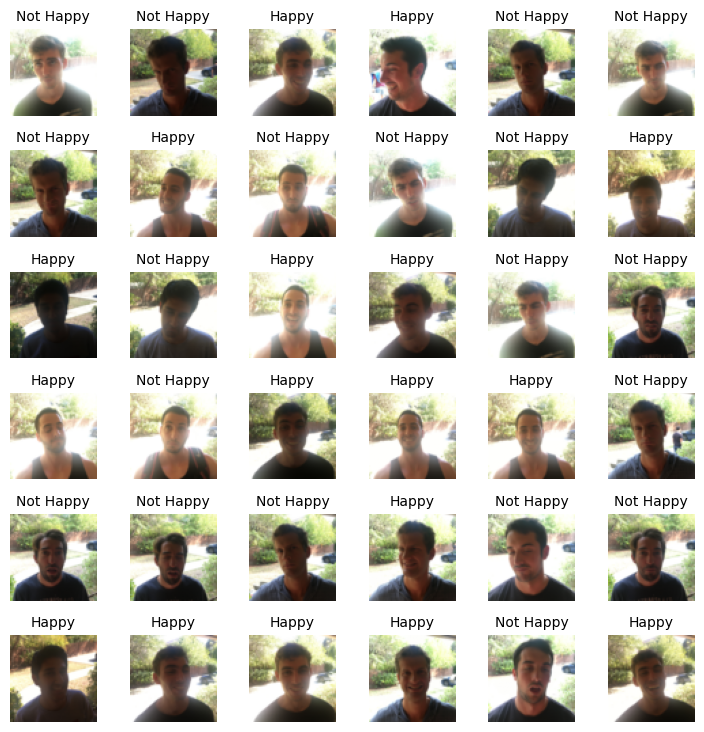

In [43]:
W_grid = 6
L_grid = 6

fig, axes = plt.subplots(L_grid, W_grid, figsize = (9,9))

axes = axes.ravel() # flaten the L_grid x W_grid matrix into L_grid * W_grid array

n_training = len(train_x) # get the length of the training dataset

for i in np.arange(0, W_grid * L_grid): # create evenly spaces variables

    index = np.random.randint(0, n_training)
    axes[i].imshow(train_x[index])

    if train_y[index] == 1:
        axes[i].set_title("Happy", fontsize = 10)
    else:
        axes[i].set_title("Not Happy", fontsize = 10)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

### 2.2.4 Plot Utility Methods

The following code is used to plot accuracy and loss histories for each model experiment.

In [6]:
def plot(training_results, validation_results, results_type, model_name):
    fig = plt.figure(figsize=[8, 6])

    plt.plot(training_results, 'r', linewidth=3.0)
    plt.plot(validation_results, 'b', linewidth=3.0)
    plt.legend(['Training ' + results_type, 'Validation ' + results_type], fontsize=18)
    plt.xlabel('Epochs', fontsize=16)
    plt.ylabel(results_type, fontsize=16)
    plt.title(results_type + ' of ' + model_name, fontsize=16)


def plot_accuracy(history, model_name):
    plot(history.history['accuracy'], history.history['val_accuracy'], 'Accuracy', model_name)


def plot_loss(history, model_name):
    plot(history.history['loss'], history.history['val_loss'], 'Loss', model_name)

### 2.2.5 Custom CNN Model

**TODO**: Build a custom CNN model to solve the problem.

Model guidelines **(You need to follow them)**:

1. [Input](https://keras.io/api/layers/core_layers/input/) Layer.
2. [ZeroPadding2D](https://keras.io/api/layers/reshaping_layers/zero_padding2d/) Layer.
3. [Conv2D](https://keras.io/api/layers/convolution_layers/convolution2d/) Layer.
4. [BatchNormalization](https://keras.io/api/layers/normalization_layers/batch_normalization/) Layer. You can read [this article](https://kharshit.github.io/blog/2018/12/28/why-batch-normalization) to learn more about BatchNormalization.
5. Relu [Activation](https://keras.io/api/layers/core_layers/activation/).
6. [MaxPooling2D](https://keras.io/api/layers/pooling_layers/max_pooling2d/) Layer.
7. [Flatten](https://keras.io/api/layers/reshaping_layers/flatten/) Layer.
8. [Dense](https://keras.io/api/layers/core_layers/dense/) with Sigmoid activation (one perceptron).

**Note**: If you made the required model, you can make other custom CNN models **if you wish** to further improve the accuracy, but in other code cells however.

**Note**: the code provided below uses the tensorflow [functional API](https://www.tensorflow.org/guide/keras/functional) in building the model.

**Make sure to add the following to the report:**


*   The plot and accuracy achieved using the custom model at the end of the notebook (1.1 in the report)
*   **Optional**: The changes, plots, and accuracies achieved using other custom model variations (the optional question in part 1 in the report)



In [7]:
def CustomCNN(input_shape):
    """
    Implementation of the Custom CNN.
    Args:
        input_shape () shape of the images of the dataset

    Returns:
        model (Keras.Model): CNN Custom Model
        model_name (Str): The name of the model
    """

    ### START CODE HERE ###

    # Input layer
    X_input = Input(input_shape)

    # Zero-padding
    X = ZeroPadding2D((3, 3))(X_input)

    # CONV -> BN -> RELU
    X = Conv2D(filters=32, kernel_size=(7,7), strides=(1,1), name='conv0')(X)
    X = BatchNormalization(axis=3, name='bn0')(X)
    X = Activation('relu')(X)

    # MAXPOOL
    X = MaxPooling2D(pool_size=(2,2), name='max_pool')(X)

    # FLATTEN
    X = Flatten()(X)

    # Dense output layer (sigmoid for binary classification)
    Y = Dense(1, activation='sigmoid', name='fc')(X)

    # Create model
    model = Model(inputs=X_input, outputs=Y)

    ### END CODE HERE ###

    return model, "Custom CNN"

In [8]:
input_shape = train_x.shape[1:]

model, model_name = CustomCNN(input_shape)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_x, train_y,
                    epochs=20,
                    batch_size=32,
                    validation_data=(test_x, test_y))

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.6483 - loss: 1.1951 - val_accuracy: 0.5533 - val_loss: 1.4163
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8117 - loss: 0.4873 - val_accuracy: 0.5333 - val_loss: 0.6517
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8917 - loss: 0.2403 - val_accuracy: 0.5933 - val_loss: 0.7815
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9417 - loss: 0.1685 - val_accuracy: 0.6733 - val_loss: 0.5369
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9483 - loss: 0.1401 - val_accuracy: 0.8133 - val_loss: 0.4415
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9750 - loss: 0.1028 - val_accuracy: 0.8000 - val_loss: 0.4137
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9817 - loss: 0.0696 - val_accuracy: 0.8667 - val_loss: 0.3862
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9833 - loss: 0.0740 - val_accuracy: 0.8867 - 

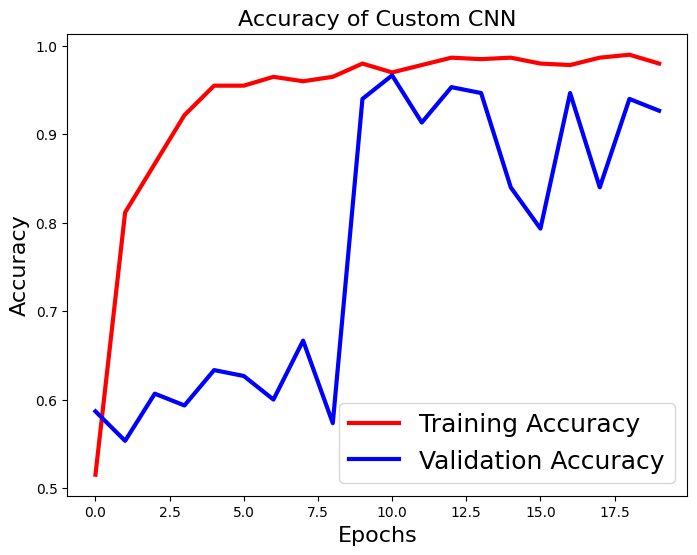

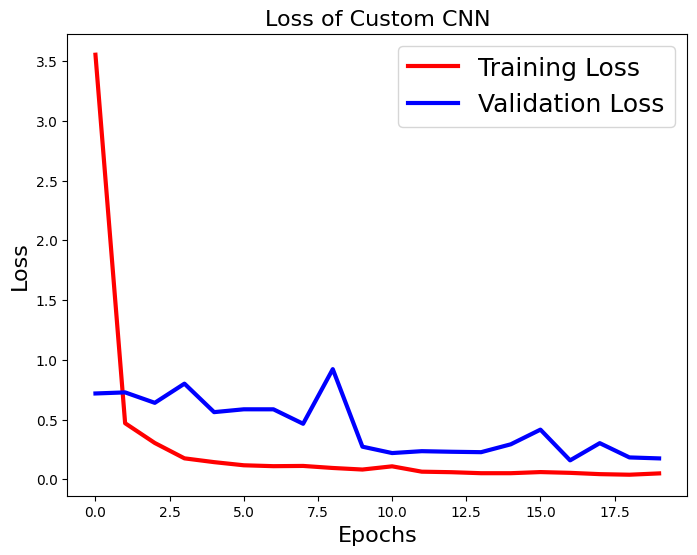

In [16]:
plot_accuracy(history, model_name)
plot_loss(history, model_name)

In [24]:
# Final training accuracy
train_acc = history.history['accuracy'][-1]

# Final validation accuracy
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")


Final Training Accuracy: 0.9900
Final Validation Accuracy: 0.9533


### 2.2.6 CNN Use Case No.1: VGG

![VGG Architecture](https://github.com/sherifmost/DeepLearning/blob/master/Labs/lab3/vgg.png?raw=1)

**Note**: this ia a show case to help you do the same with other use cases.

**TODO**: Try different variations for VGG:

1. [VGG16](https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16)
2. [VGG19](https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG19)

**Note**: *You will need to experiment all of them both pretrained (both with or without layers freezing) and also untrained, in the test section.*

**Make sure to add the following to the report:**


*   The plots and accuracy achieved using VGG16 untrained, pre-trained, and pre-trained with layer freezing with different number of frozen layers (from 2.1 till 2.5 in the report)
*   The plots and accuracy achieved using VGG19 untrained, pre-trained, and pre-trained with layer freezing with different number of frozen layers (from 2.6 till 2.10 in the report)



In [26]:
def VGG(pretrained = True, input_shape = (64, 64, 3), model_name = "VGG16"):
    """
    Returns VGG Keras Model
    Args:
        pretrained (Bool): Whether get a pretrained model or not
        input_shape (Tuple): To create the input layer, should match the image resolution
        model_name (str): String to capture the model name
    Examples:
        VGG(True) -> Model, "Pretrained VGG16"
    """
    if(pretrained):
        model_name = "Pretrained " + model_name
        base_model = applications.vgg16.VGG16(weights='imagenet', include_top=False, input_shape=input_shape, pooling='none')
    else:
        model_name = "Untrained " + model_name
        base_model = applications.vgg16.VGG16(weights=None, include_top=False, input_shape=input_shape, pooling='none')

    return base_model, model_name

In [27]:
def build_transfer_model(base_model, input_shape):

    X_input = Input(input_shape)

    X = base_model(X_input)

    X = Flatten()(X)
    X = Dense(128, activation='relu')(X)
    X = Dropout(0.5)(X)

    Y = Dense(1, activation='sigmoid')(X)

    model = Model(inputs=X_input, outputs=Y)

    return model

In [28]:
def freeze_layers(base_model, num_layers):

    for layer in base_model.layers[:num_layers]:
        layer.trainable = False

    for layer in base_model.layers[num_layers:]:
        layer.trainable = True

    return base_model

In [29]:
def train_model(base_model, model_name):

    model = build_transfer_model(base_model, input_shape)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_x,
        train_y,
        epochs=20,
        batch_size=32,
        validation_data=(test_x, test_y)
    )

    plot_accuracy(history, model_name)
    plot_loss(history, model_name)

    loss, acc = model.evaluate(test_x, test_y)

    print(model_name, "accuracy =", acc)

    return acc

2.1 Untrained

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 763ms/step - accuracy: 0.4567 - loss: 0.6962 - val_accuracy: 0.4400 - val_loss: 0.6933
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4917 - loss: 0.6931 - val_accuracy: 0.5600 - val_loss: 0.6930
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.4983 - loss: 0.6935 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.5067 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6933
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4817 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6932
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4983 - loss: 0.6933 - val_accuracy: 0.5600 - val_loss: 0.6929
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.5000 - loss: 0.6929 - val_accuracy: 0.5600 - val_loss: 0.6927
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.4850 - loss: 0.6932 - val_accuracy: 0.4400 -

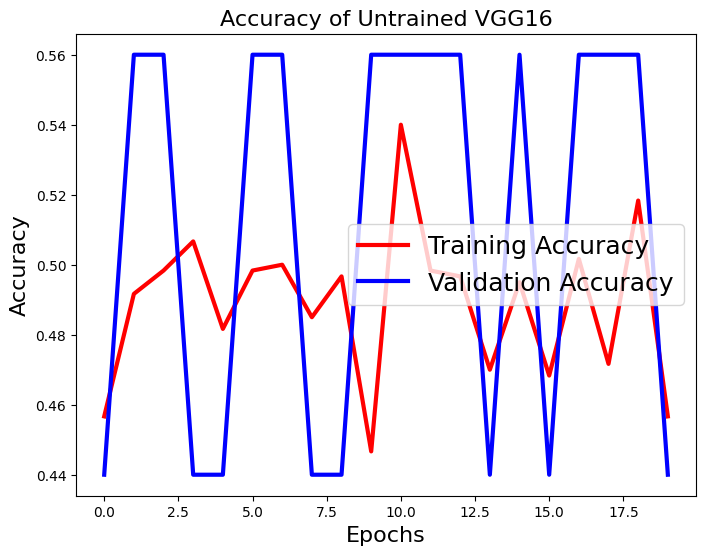

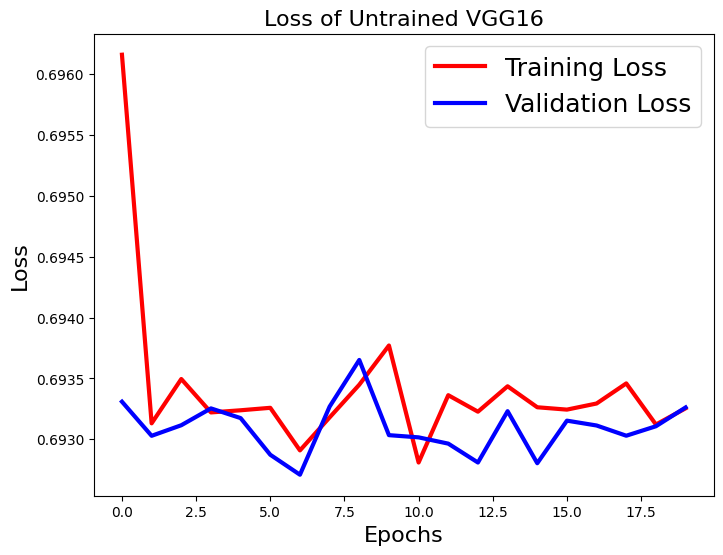

In [25]:
base_model, model_name = VGG(pretrained=False, input_shape=input_shape)

acc_vgg16_untrained = train_model(base_model, model_name)

2.2 Pretrained VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - accuracy: 0.6417 - loss: 0.6364 - val_accuracy: 0.6933 - val_loss: 0.5420
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8250 - loss: 0.3928 - val_accuracy: 0.9133 - val_loss: 0.3318
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8900 - loss: 0.2932 - val_accuracy: 0.9200 - val_loss: 0.2731
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9350 - loss: 0.2382 - val_accuracy: 0.9133 - val_loss: 0.2421
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9300 - loss: 0.2079 - val_accuracy: 0.9400 - val_loss: 0.1957
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9617 - loss: 0.1632 - val_accuracy: 0.9267 - val_loss: 0.1930
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9533 - loss: 0.1523 - val_accuracy: 0.9667 - val_loss: 0.1462
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accura

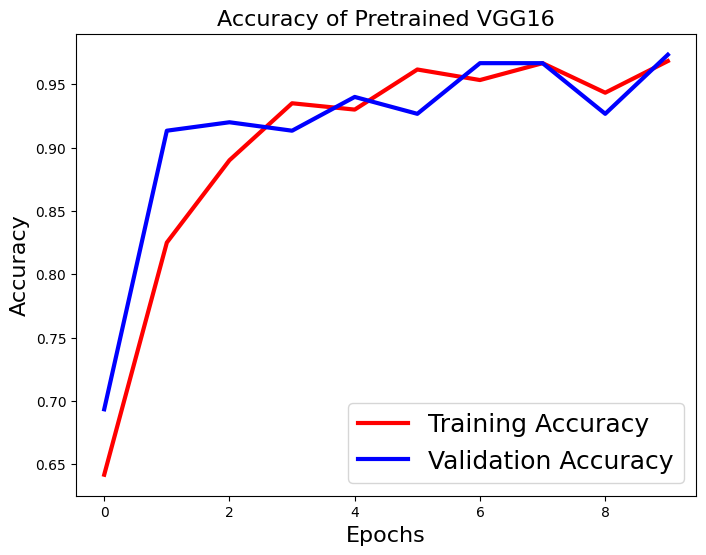

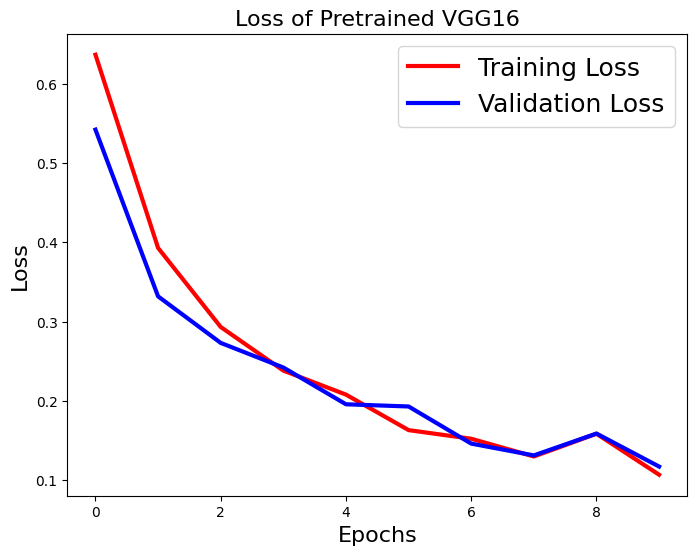

In [26]:
# Load VGG16 model with pretrained weights
base_model, model_name = VGG(pretrained=True, input_shape=input_shape)

# Set all layers as non-trainable
for layer in base_model.layers:
    layer.trainable = False

# Build the transfer learning model
transfer_model = build_transfer_model(base_model, input_shape)

# Compile the model with Adam optimizer
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
training_history = transfer_model.fit(
    train_x,
    train_y,
    epochs=10,
    batch_size=32,
    validation_data=(test_x, test_y)
)

# Plot the accuracy and loss curves
plot_accuracy(training_history, model_name)
plot_loss(training_history, model_name)

# Evaluate the model performance on the test set
test_loss, test_accuracy = transfer_model.evaluate(test_x, test_y)

# Print the final accuracy
print(f"Accuracy of the Pre-trained VGG16 model: {test_accuracy}")

2.3

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 372ms/step - accuracy: 0.4800 - loss: 2.3220 - val_accuracy: 0.4400 - val_loss: 0.9177
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5133 - loss: 0.7230 - val_accuracy: 0.4400 - val_loss: 0.7125
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.4867 - loss: 0.7211 - val_accuracy: 0.4400 - val_loss: 0.7130
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5100 - loss: 0.7115 - val_accuracy: 0.5600 - val_loss: 0.6913
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5517 - loss: 0.6995 - val_accuracy: 0.4400 - val_loss: 0.7082
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.5150 - loss: 0.7028 - val_accuracy: 0.5600 - val_loss: 0.6860
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.5067 - loss: 0.6992 - val_accuracy: 0.4400 - val_loss: 0.6983
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4650 - loss: 0.7056 - val_accuracy: 0.4400 -

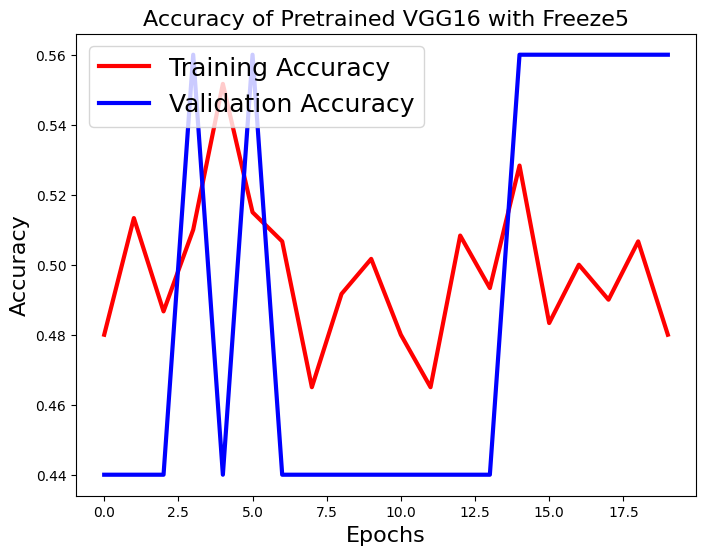

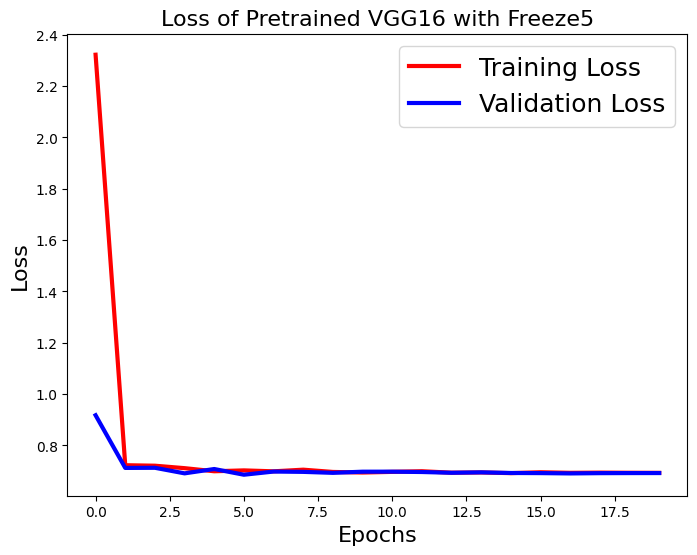

In [28]:
# Load the pre-trained VGG16 model
base_model, model_name = VGG(pretrained=True, input_shape=input_shape)

# Freeze the first 5 layers of the model
base_model = freeze_layers(base_model, 5)

# Train the model with the modified base model
vgg16_freeze5_accuracy = train_model(base_model, model_name + " with Freeze5")

# Print out the accuracy obtained for this configuration
print(f"VGG16 with 5 frozen layers achieved accuracy: {vgg16_freeze5_accuracy}")

2.4

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - accuracy: 0.5017 - loss: 1.1367 - val_accuracy: 0.5600 - val_loss: 0.6922
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5083 - loss: 0.7008 - val_accuracy: 0.5600 - val_loss: 0.6920
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5017 - loss: 0.6943 - val_accuracy: 0.5600 - val_loss: 0.6919
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5600 - val_loss: 0.6919
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5000 - loss: 0.6934 - val_accuracy: 0.5600 - val_loss: 0.6921
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5600 - val_loss: 0.6922
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5600 - val_loss: 0.6924
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4983 - loss: 0.6933 - val_accuracy: 0.5600 -

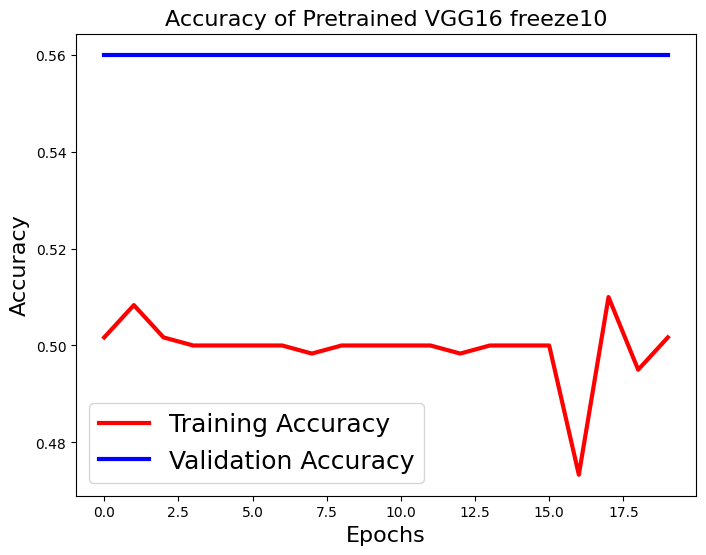

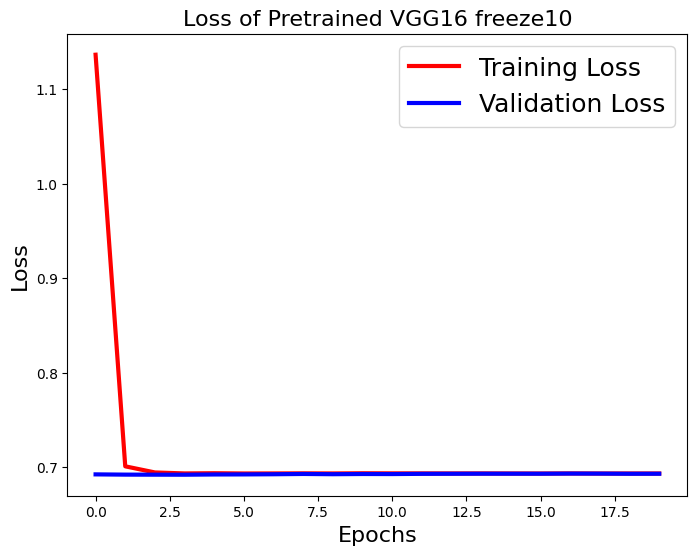

In [29]:
# Load the pre-trained VGG16 model
base_model, model_name = VGG(pretrained=True, input_shape=input_shape)

# Freeze the first 10 layers of the model
base_model = freeze_layers(base_model, 10)

# Train the model with the modified base model
vgg16_freeze10_accuracy = train_model(base_model, model_name + " freeze10")

# Print out the accuracy obtained for this configuration
print(f"VGG16 with 10 frozen layers achieved accuracy: {vgg16_freeze10_accuracy}")

2.5

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 210ms/step - accuracy: 0.5417 - loss: 1.0728 - val_accuracy: 0.5333 - val_loss: 0.6930
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.4917 - loss: 0.6966 - val_accuracy: 0.4400 - val_loss: 0.6935
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.4400 - val_loss: 0.6936
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6937
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.4400 - val_loss: 0.6935
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6936
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6935
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4983 - loss: 0.6931 - val_accuracy: 0.4400 - 

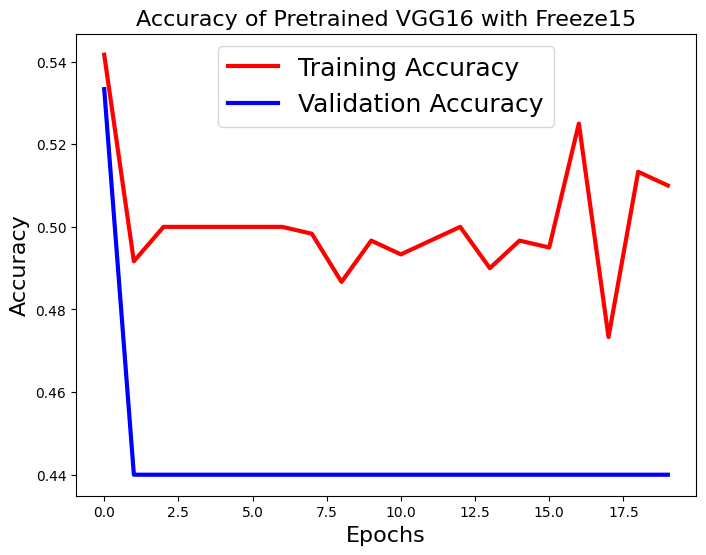

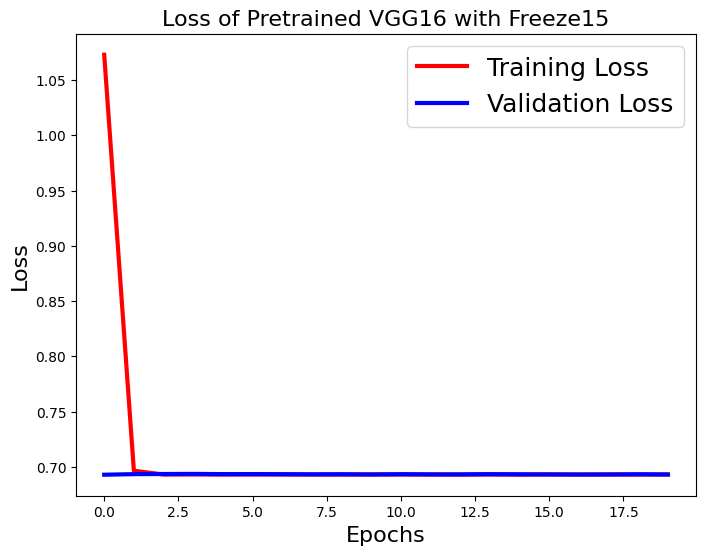

In [30]:
# Load the VGG16 model with pre-trained weights
base_model, model_name = VGG(pretrained=True, input_shape=input_shape)

# Freeze the first 15 layers of the VGG16 model
base_model = freeze_layers(base_model, num_layers=15)

# Train the model with the modified architecture
vgg16_freeze15_accuracy = train_model(base_model, model_name + " with Freeze15")

# Output the accuracy achieved by the model with 15 frozen layers
print(f"VGG16 with 15 frozen layers achieved accuracy: {vgg16_freeze15_accuracy}")

VGG19 establishing

In [31]:
from keras.applications import vgg19

def VGG(pretrained=True, input_shape=(64, 64, 3), model_name="VGG19"):
    """
    Returns VGG Keras Model
    Args:
        pretrained (Bool): Whether get a pretrained model or not
        input_shape (Tuple): Image resolution
        model_name (str): "VGG16" or "VGG19"
    """

    if model_name == "VGG19":
        model_fn = vgg19.VGG19
    else:
        raise ValueError("model_name must be 'VGG19'")

    if pretrained:
        name = "Pretrained " + model_name
        base_model = model_fn(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape,
            pooling='none'
        )
    else:
        name = "Untrained " + model_name
        base_model = model_fn(
            weights=None,
            include_top=False,
            input_shape=input_shape,
            pooling='none'
        )

    return base_model, name

2.6

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 428ms/step - accuracy: 0.4850 - loss: 0.6980 - val_accuracy: 0.4400 - val_loss: 0.6939
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.4817 - loss: 0.6936 - val_accuracy: 0.4400 - val_loss: 0.6934
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.5133 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6936
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.4917 - loss: 0.6933 - val_accuracy: 0.4400 - val_loss: 0.6936
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.4950 - loss: 0.6933 - val_accuracy: 0.4400 - val_loss: 0.6939
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.4950 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6936
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.4883 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6934
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.5033 - loss: 0.6930 - val_accuracy: 0

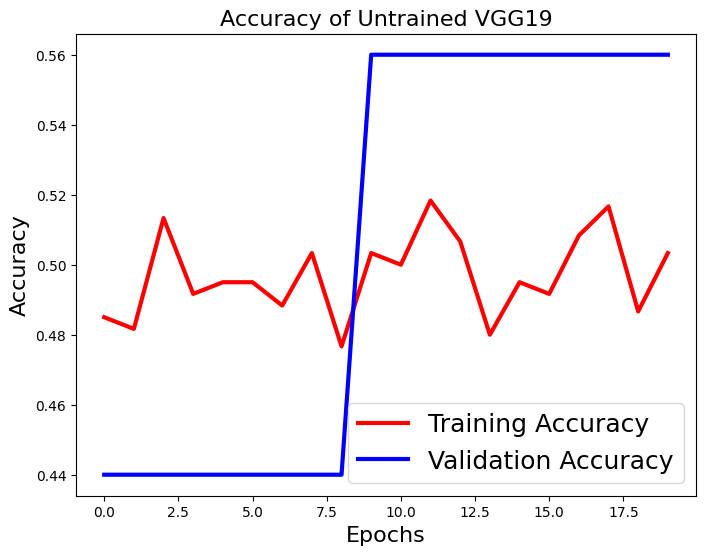

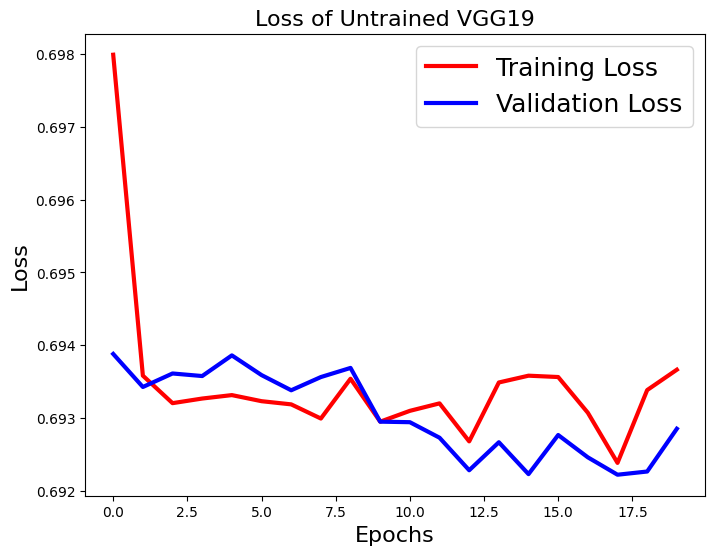

In [32]:
# Load the untrained VGG19 model
base_model, model_name = VGG(pretrained=False, input_shape=input_shape, model_name="VGG19")

# Train the model with the untrained VGG19 base
vgg19_untrained_accuracy = train_model(base_model, model_name)

# Print out the accuracy achieved for the untrained VGG19 model
print(f"{model_name} achieved accuracy: {vgg19_untrained_accuracy}")

2.7

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 466ms/step - accuracy: 0.5250 - loss: 1.1900 - val_accuracy: 0.4400 - val_loss: 0.7004
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.4983 - loss: 0.7246 - val_accuracy: 0.4400 - val_loss: 0.6931
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.4833 - loss: 0.7106 - val_accuracy: 0.4400 - val_loss: 0.6951
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.5183 - loss: 0.6960 - val_accuracy: 0.4400 - val_loss: 0.7003
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.5017 - loss: 0.7049 - val_accuracy: 0.4400 - val_loss: 0.6997
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.4950 - loss: 0.6964 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.5117 - loss: 0.6964 - val_accuracy: 0.4400 - val_loss: 0.6948
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.5300 - loss: 0.6933 - val_accuracy: 0

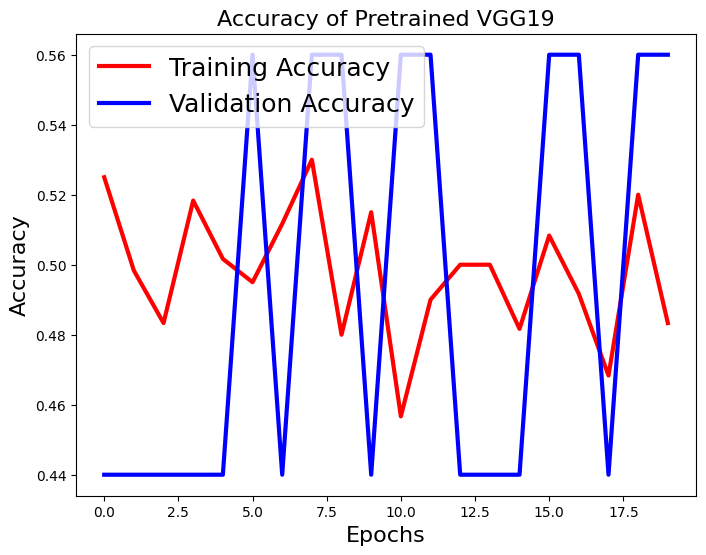

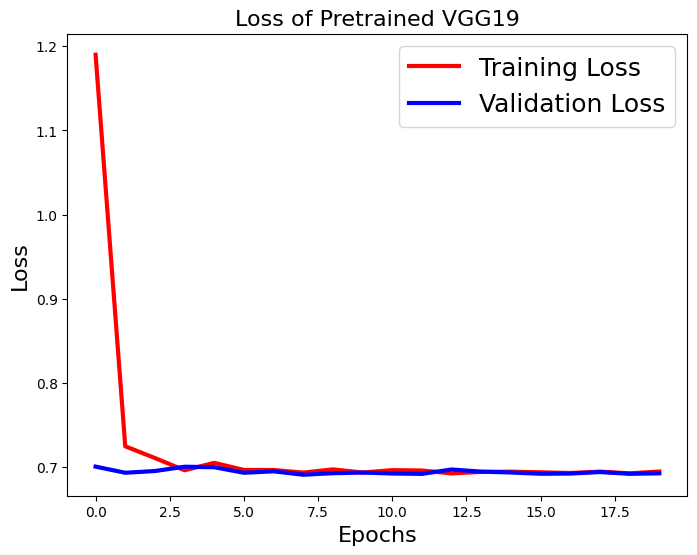

In [34]:
# Load the pre-trained VGG19 model
base_model, model_name = VGG(pretrained=True, input_shape=input_shape, model_name="VGG19")

# Train the model with the pre-trained VGG19 base
vgg19_pretrained_accuracy = train_model(base_model, model_name)

# Print out the accuracy achieved for the pre-trained VGG19 model
print(f"{model_name} achieved accuracy: {vgg19_pretrained_accuracy}")

2.8

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 463ms/step - accuracy: 0.5150 - loss: 1.0871 - val_accuracy: 0.4400 - val_loss: 0.7160
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.4983 - loss: 0.7101 - val_accuracy: 0.5600 - val_loss: 0.6912
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.4867 - loss: 0.7015 - val_accuracy: 0.4400 - val_loss: 0.7031
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.4917 - loss: 0.7003 - val_accuracy: 0.4400 - val_loss: 0.7049
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.5150 - loss: 0.6950 - val_accuracy: 0.4400 - val_loss: 0.6950
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.5433 - loss: 0.6903 - val_accuracy: 0.5600 - val_loss: 0.6876
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.4933 - loss: 0.7036 - val_accuracy: 0.4400 - val_loss: 0.6957
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.5200 - loss: 0.6965 - val_accuracy: 0

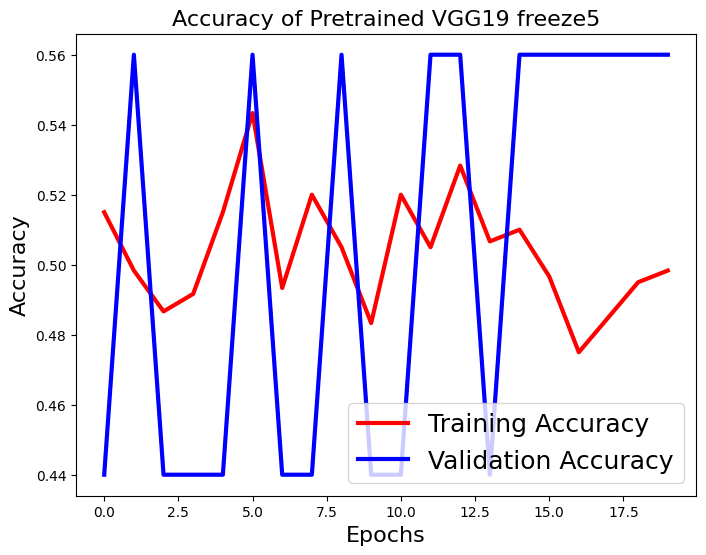

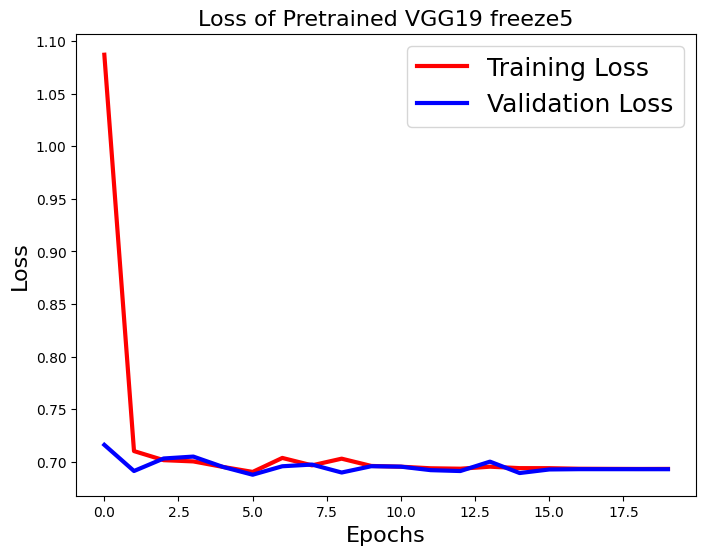

In [35]:
# Load the pre-trained VGG19 model
base_model, model_name = VGG(pretrained=True, input_shape=input_shape, model_name="VGG19")

# Freeze the first 5 layers of the model
base_model = freeze_layers(base_model, 5)

# Train the model with the frozen layers
vgg19_freeze5_accuracy = train_model(base_model, model_name + " freeze5")

# Print out the accuracy achieved for the VGG19 model with 5 frozen layers
print(f"{model_name} with 5 frozen layers achieved accuracy: {vgg19_freeze5_accuracy}")

2.9

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 425ms/step - accuracy: 0.5350 - loss: 1.8960 - val_accuracy: 0.4400 - val_loss: 0.7068
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.5067 - loss: 0.7150 - val_accuracy: 0.4400 - val_loss: 0.7128
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5217 - loss: 0.7034 - val_accuracy: 0.5600 - val_loss: 0.6861
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.4850 - loss: 0.7070 - val_accuracy: 0.5600 - val_loss: 0.6924
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.4817 - loss: 0.6980 - val_accuracy: 0.5600 - val_loss: 0.6858
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4850 - loss: 0.7188 - val_accuracy: 0.5600 - val_loss: 0.6862
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4883 - loss: 0.7008 - val_accuracy: 0.4400 - val_loss: 0.7072
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4867 - loss: 0.7067 - val_accuracy: 0.5600 

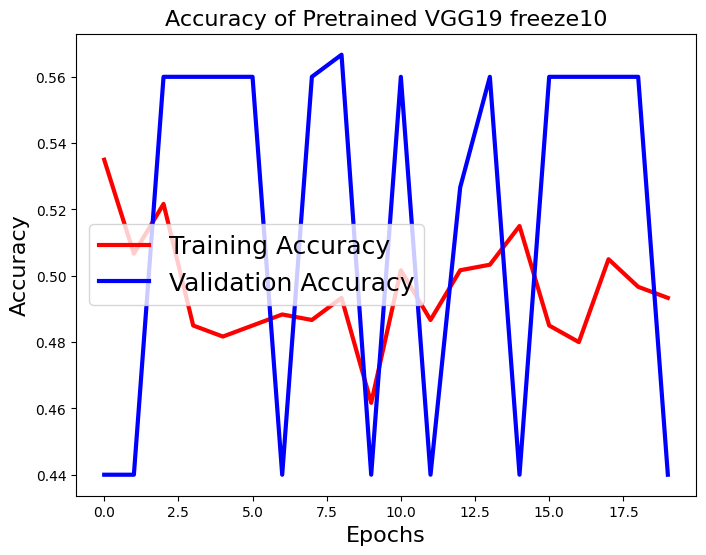

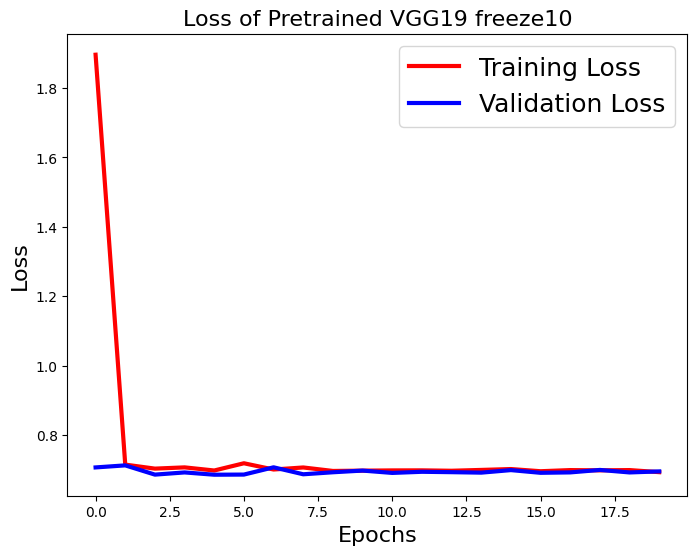

In [36]:
# Load the pre-trained VGG19 model
base_model, model_name = VGG(pretrained=True, input_shape=input_shape, model_name="VGG19")

# Freeze the first 10 layers of the model
base_model = freeze_layers(base_model, 10)

# Train the model with the frozen layers
vgg19_freeze10_accuracy = train_model(base_model, model_name + " freeze10")

# Print out the accuracy achieved for the VGG19 model with 10 frozen layers
print(f"{model_name} with 10 frozen layers achieved accuracy: {vgg19_freeze10_accuracy}")

2.10

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - accuracy: 0.5183 - loss: 1.2601 - val_accuracy: 0.5600 - val_loss: 0.7377
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5050 - loss: 0.7054 - val_accuracy: 0.5600 - val_loss: 0.6878
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5100 - loss: 0.6947 - val_accuracy: 0.4400 - val_loss: 0.7048
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4750 - loss: 0.7122 - val_accuracy: 0.4533 - val_loss: 0.6932
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5050 - loss: 0.7014 - val_accuracy: 0.5600 - val_loss: 0.6847
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.5067 - loss: 0.6960 - val_accuracy: 0.4400 - val_loss: 0.6984
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5050 - loss: 0.6946 - val_accuracy: 0.5600 - val_loss: 0.6927
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4967 - loss: 0.6933 - val_accuracy: 0.5600 -

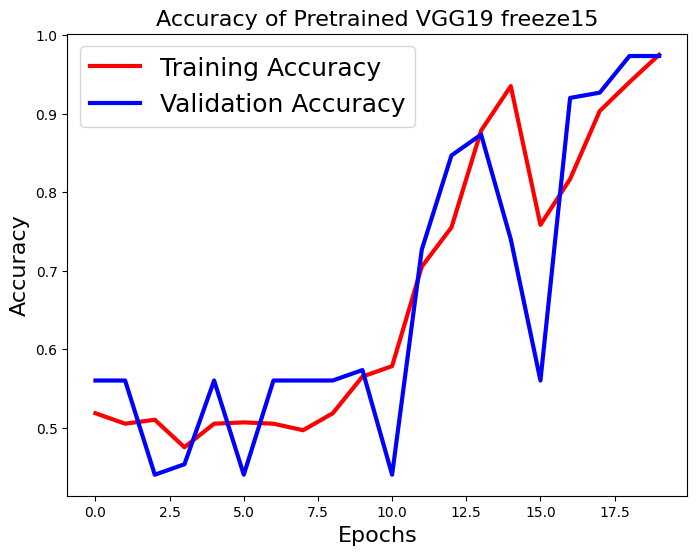

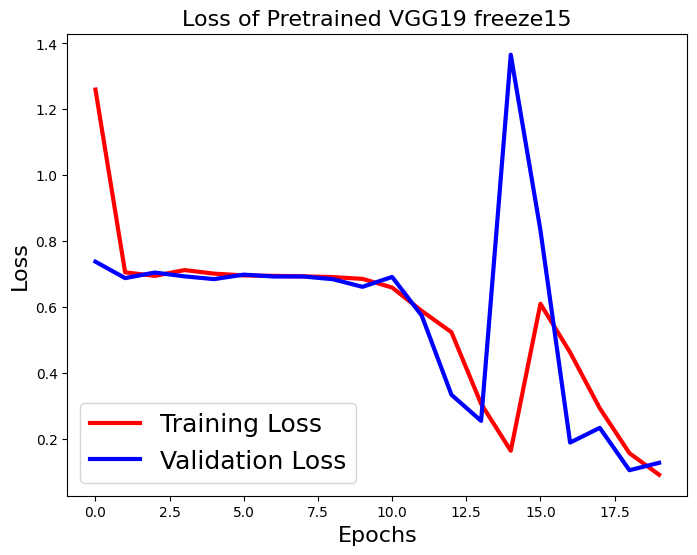

In [37]:
# Load the pre-trained VGG19 model
base_model, model_name = VGG(pretrained=True, input_shape=input_shape, model_name="VGG19")

# Freeze the first 15 layers of the model
base_model = freeze_layers(base_model, 15)

# Train the model with the frozen layers
vgg19_freeze15_accuracy = train_model(base_model, model_name + " freeze15")

# Print out the accuracy achieved for the VGG19 model with 15 frozen layers
print(f"{model_name} with 15 frozen layers achieved accuracy: {vgg19_freeze15_accuracy}")

### 2.2.7 CNN Use Case No.2: Residual Connections-based Networks

![VGG vs ResNet](https://github.com/sherifmost/DeepLearning/blob/master/Labs/lab3/VGG_vs_ResNet.png?raw=1)

**TODO**: Follow the same style for the above mentioned VGG and experiment the following Networks:

1. [ResNet50](https://www.tensorflow.org/api_docs/python/tf/keras/applications/ResNet50)
2. [ResNet101](https://www.tensorflow.org/api_docs/python/tf/keras/applications/ResNet101)
3. [InceptionResNetV2](https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_resnet_v2/InceptionResNetV2) this network builds on the inception network architecture and incorporates [residual connections](https://towardsdatascience.com/what-is-residual-connection-efb07cab0d55), you can read more about it [here](https://paperswithcode.com/method/inception-resnet-v2#:~:text=Inception%2DResNet%2Dv2%20is%20a,stage%20of%20the%20Inception%20architecture).

**Note 1**: *You will need to experiment all of them both pretrained (both with or without layers freezing) and also untrained, in the test section.*

**Note 2**: For very deep networks like **InceptionResNetV2**, the size of the input might get reduced too much and an error might be produced, **you need to fix this issue by either resizing the images (preferred) or by adding padding (not preferred)**.

To resize the image you *can* follow the following steps (*just some possible guidelines)*:

*   You can use [cv2.resize](https://www.geeksforgeeks.org/image-resizing-using-opencv-python/) or [tf.image.resize](https://www.tensorflow.org/api_docs/python/tf/image/resize).
*   Make a function similar to preprocess_data() but instead resize the train and test images before returning them at the end
*   When you train the model that is causing the error, call the new function you made to obtain the training and testing data instead of calling the original preprocess_data() *(as was done at the beggining of the notebook)*



**Make sure to add the following to the report:**


*   The plots and accuracy achieved using ResNet50 untrained, pre-trained, and pre-trained with layer freezing with different number of frozen layers (from 3.1 till 3.5 in the report)
*   The plots and accuracy achieved using ResNet101 untrained, pre-trained, and pre-trained with layer freezing with different number of frozen layers (from 3.6 till 3.10 in the report)
*   The plots and accuracy achieved using InceptionResNetV2 untrained, pre-trained, and pre-trained with layer freezing with different number of frozen layers (from 3.11 till 3.15 in the report)



RESNET50

In [13]:
def ResNet(pretrained=True, input_shape=(64, 64, 3), model_name="ResNet50"):
    """
    Returns ResNet Keras Model
    """

    if model_name == "ResNet50":
        model_fn = applications.resnet50.ResNet50
    elif model_name == "ResNet101":
        model_fn = applications.resnet.ResNet101
    elif model_name == "InceptionResNetV2":
        model_fn = applications.inception_resnet_v2.InceptionResNetV2
    else:
        raise ValueError("Unsupported model name")

    if pretrained:
        name = "Pretrained " + model_name
        base_model = model_fn(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape,
            pooling='none'
        )
    else:
        name = "Untrained " + model_name
        base_model = model_fn(
            weights=None,
            include_top=False,
            input_shape=input_shape,
            pooling='none'
        )

    return base_model, name

3.1

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.4600 - loss: 3.0300 - val_accuracy: 0.5600 - val_loss: 0.6908
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5000 - loss: 0.6942 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4400 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6932
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5133 - loss: 0.6931 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4667 - loss: 0.6932 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5600 - va

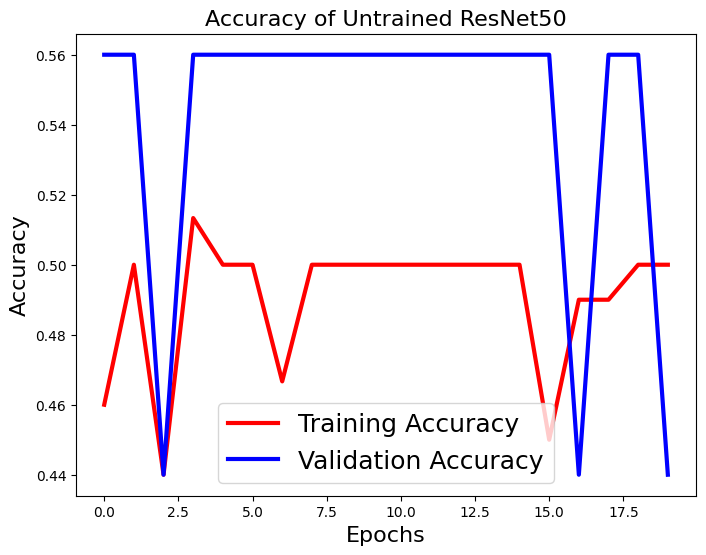

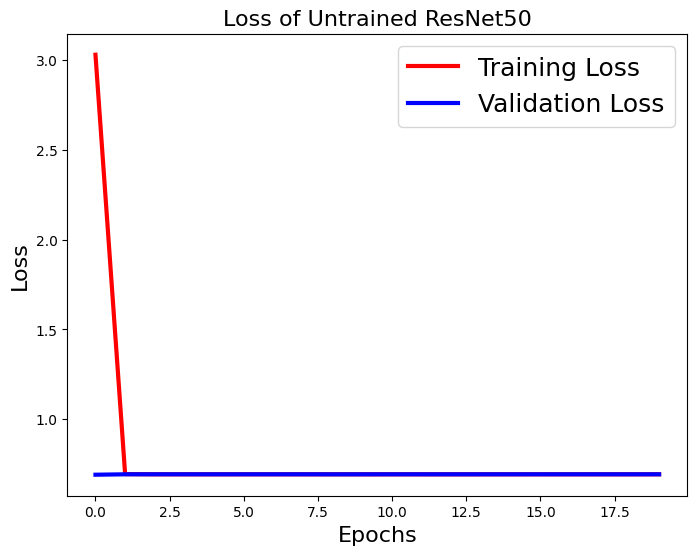

In [39]:
# Load the untrained ResNet50 model
base_model, model_name = ResNet(pretrained=False, input_shape=input_shape, model_name="ResNet50")

# Train the model with the untrained ResNet50 base
resnet50_untrained_accuracy = train_model(base_model, model_name)

# Print out the accuracy achieved for the untrained ResNet50 model
print(f"{model_name} achieved accuracy: {resnet50_untrained_accuracy}")

3.2

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7900 - loss: 0.7373 - val_accuracy: 0.4400 - val_loss: 25120.2207
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8950 - loss: 0.4696 - val_accuracy: 0.4400 - val_loss: 868712.1875
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9650 - loss: 0.2621 - val_accuracy: 0.4400 - val_loss: 1044563.7500
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9250 - loss: 0.5675 - val_accuracy: 0.4400 - val_loss: 80082.3438
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9517 - loss: 1.0841 - val_accuracy: 0.4400 - val_loss: 8158.4844
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9483 - loss: 0.6484 - val_accuracy: 0.4400 - val_loss: 167.8586
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9017 - loss: 0.9022 - val_accuracy: 0.5600 - val_loss: 53.7342
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━

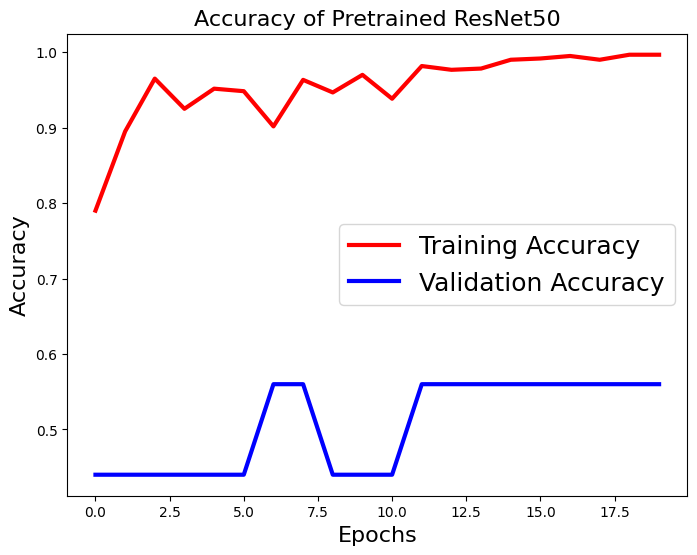

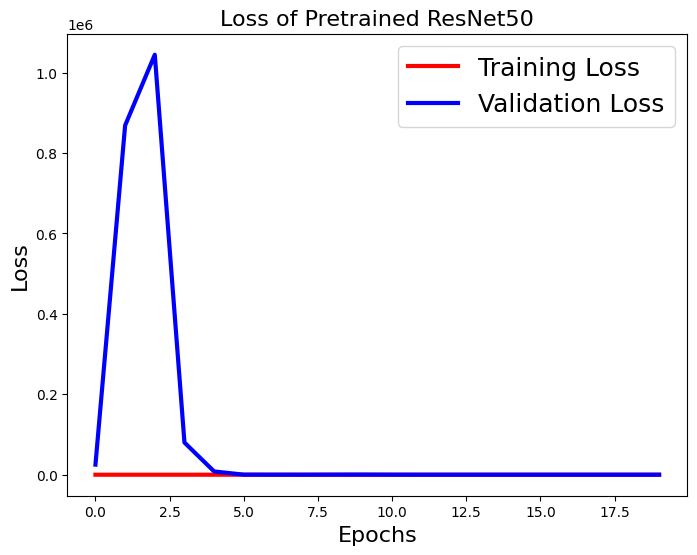

In [26]:
# Load the pre-trained ResNet50 model
base_model, model_name = ResNet(pretrained=True, input_shape=input_shape, model_name="ResNet50")

# Train the model with the pre-trained ResNet50 base
resnet50_pretrained_accuracy = train_model(base_model, model_name)

# Output the accuracy for the pre-trained ResNet50 model
print(f"Accuracy for {model_name}: {resnet50_pretrained_accuracy}")

3.3

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8233 - loss: 0.6500 - val_accuracy: 0.4400 - val_loss: 1525.9033
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8733 - loss: 0.5377 - val_accuracy: 0.4400 - val_loss: 30042.5762
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9450 - loss: 0.4093 - val_accuracy: 0.4400 - val_loss: 3595.7676
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9517 - loss: 0.4261 - val_accuracy: 0.4400 - val_loss: 650.4031
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9417 - loss: 0.4734 - val_accuracy: 0.4400 - val_loss: 4576.1045
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9700 - loss: 0.1049 - val_accuracy: 0.4400 - val_loss: 1827.4950
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9767 - loss: 0.0980 - val_accuracy: 0.4400 - val_loss: 313.1901
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9833 - loss: 0.0473 - val_a

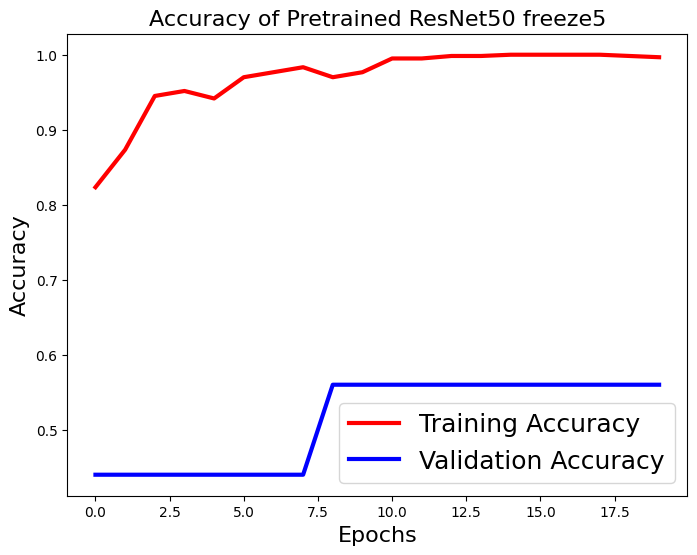

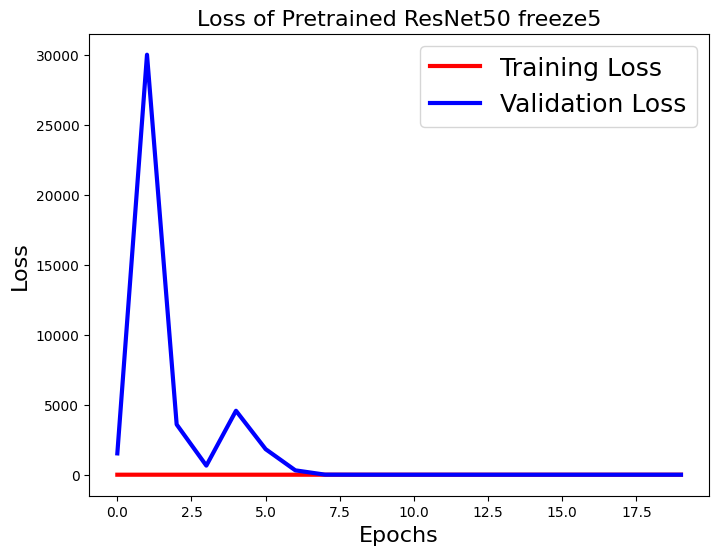

In [27]:
# Load the pre-trained ResNet50 model
base_model, model_name = ResNet(pretrained=True, input_shape=input_shape, model_name="ResNet50")

# Freeze the first 5 layers of the model
base_model = freeze_layers(base_model, 5)

# Train the model with the frozen layers
resnet50_freeze5_accuracy = train_model(base_model, model_name + " freeze5")

# Output the accuracy achieved for the ResNet50 model with 5 frozen layers
print(f"{model_name} with 5 frozen layers achieved accuracy: {resnet50_freeze5_accuracy}")

3.4

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8317 - loss: 0.7294 - val_accuracy: 0.5600 - val_loss: 144.4969
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.8767 - loss: 0.3042 - val_accuracy: 0.5600 - val_loss: 16.4454
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9233 - loss: 0.1568 - val_accuracy: 0.4400 - val_loss: 2.8849
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9167 - loss: 0.3291 - val_accuracy: 0.4400 - val_loss: 1.1775
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9100 - loss: 0.2582 - val_accuracy: 0.4400 - val_loss: 1.1124
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9183 - loss: 0.2696 - val_accuracy: 0.4400 - val_loss: 1.1397
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9583 - loss: 0.1147 - val_accuracy: 0.4400 - val_loss: 1.6562
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9733 - loss: 0.1438 - val_accuracy: 0.4400 

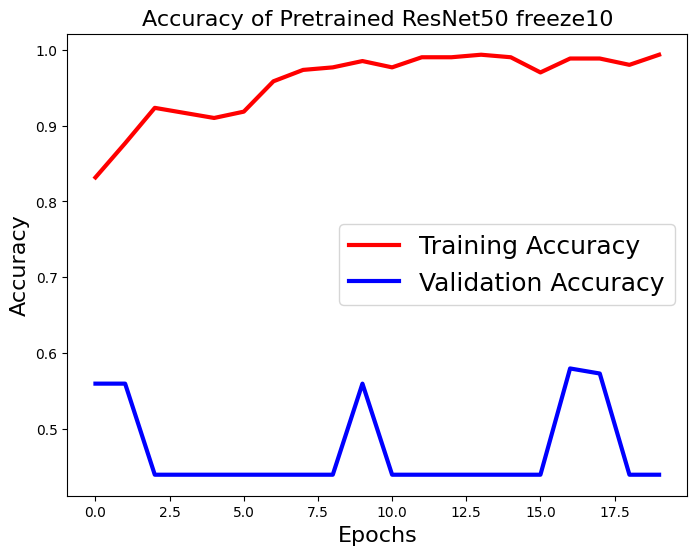

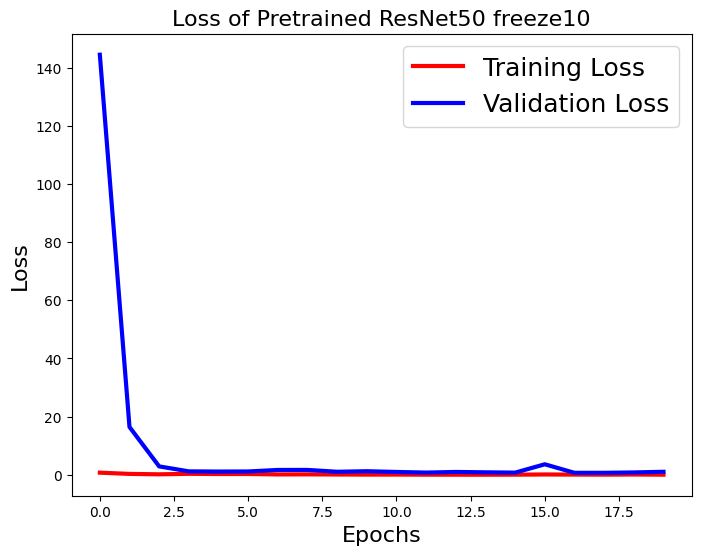

In [28]:
# Load the pre-trained ResNet50 model
base_model, model_name = ResNet(pretrained=True, input_shape=input_shape, model_name="ResNet50")

# Freeze the first 10 layers of the model
base_model = freeze_layers(base_model, 10)

# Train the model with the frozen layers
resnet50_freeze10_accuracy = train_model(base_model, model_name + " freeze10")

# Print the accuracy for the ResNet50 model with 10 frozen layers
print(f"{model_name} with 10 frozen layers achieved accuracy: {resnet50_freeze10_accuracy}")

3.5

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7900 - loss: 0.6504 - val_accuracy: 0.5600 - val_loss: 250.2866
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8783 - loss: 0.4864 - val_accuracy: 0.4400 - val_loss: 1246137.8750
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9483 - loss: 1.2510 - val_accuracy: 0.4400 - val_loss: 4727.6406
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9433 - loss: 0.1394 - val_accuracy: 0.4400 - val_loss: 488.9900
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9767 - loss: 0.0912 - val_accuracy: 0.4733 - val_loss: 0.7122
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9550 - loss: 0.1218 - val_accuracy: 0.4400 - val_loss: 1.4560
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9767 - loss: 0.0930 - val_accuracy: 0.4400 - val_loss: 1.2954
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9717 - loss: 0.0978 - val_accuracy

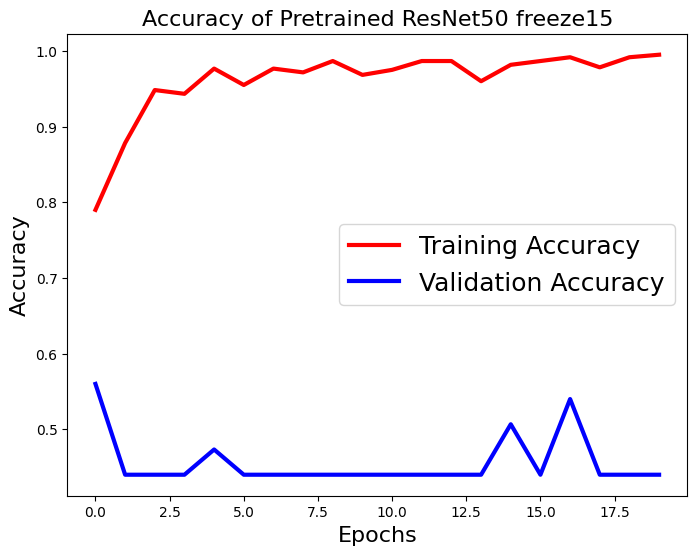

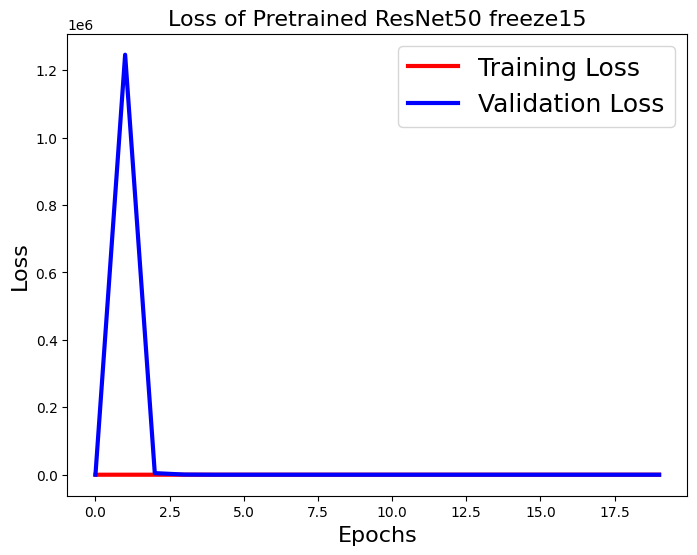

In [29]:
# Load the pre-trained ResNet50 model
base_model, model_name = ResNet(pretrained=True, input_shape=input_shape, model_name="ResNet50")

# Freeze the first 15 layers of the model
base_model = freeze_layers(base_model, 15)

# Train the model with the frozen layers
resnet50_freeze15_accuracy = train_model(base_model, model_name + " freeze15")

# Print the accuracy for the ResNet50 model with 15 frozen layers
print(f"{model_name} with 15 frozen layers achieved accuracy: {resnet50_freeze15_accuracy}")

3.6

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.5150 - loss: 2.6231 - val_accuracy: 0.5600 - val_loss: 0.6864
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.5700 - loss: 0.6871 - val_accuracy: 0.4400 - val_loss: 0.7107
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.6700 - loss: 0.5345 - val_accuracy: 0.4400 - val_loss: 0.7002
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.7767 - loss: 0.3947 - val_accuracy: 0.5600 - val_loss: 0.8254
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.8867 - loss: 0.3204 - val_accuracy: 0.5600 - val_loss: 0.8105
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.8967 - loss: 0.2917 - val_accuracy: 0.5600 - val_loss: 1.3100
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.9033 - loss: 0.2614 - val_accuracy: 0.5600 - val_loss: 1.6124
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.9117 - loss: 0.2610 - val_accuracy: 0.5

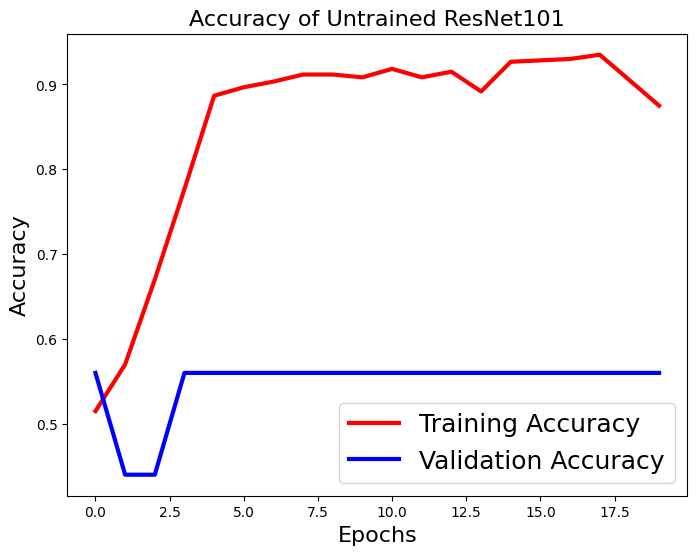

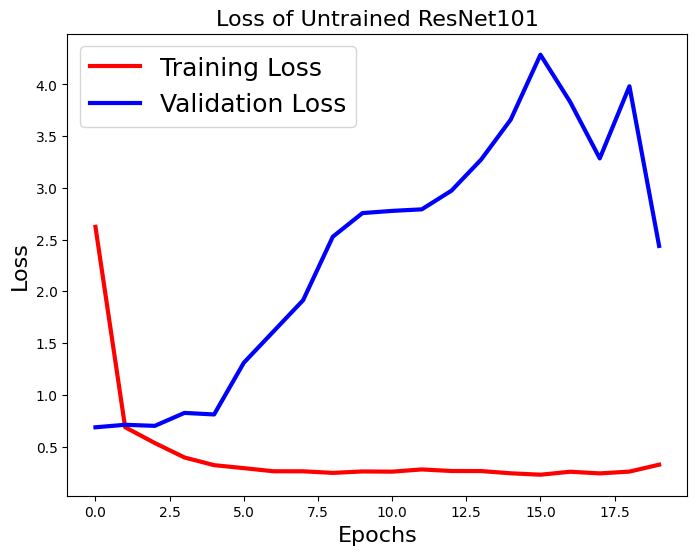

In [33]:
# Initialize ResNet101 without pretrained weights
base_model, model_name = ResNet(pretrained=False, input_shape=input_shape, model_name="ResNet101")

# Train the model with the untrained ResNet101 base
# Note: Since pretrained=False, model_name will be "Untrained ResNet101"
resnet101_untrained_accuracy = train_model(base_model, model_name)

# Print out the accuracy achieved
print(f"{model_name} achieved accuracy: {resnet101_untrained_accuracy}")

3.7

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.7500 - loss: 0.8153 - val_accuracy: 0.5600 - val_loss: 1978.6005
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8717 - loss: 0.8920 - val_accuracy: 0.5600 - val_loss: 222402.1562
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.9233 - loss: 0.2247 - val_accuracy: 0.5600 - val_loss: 59555.9805
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.9350 - loss: 0.1583 - val_accuracy: 0.5600 - val_loss: 1865.1566
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9683 - loss: 0.1215 - val_accuracy: 0.5600 - val_loss: 5739.6362
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.9783 - loss: 0.1051 - val_accuracy: 0.5600 - val_loss: 3871.2837
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.9700 - loss: 0.1200 - val_accuracy: 0.5600 - val_loss: 655.9634
Epoch 8/20
19/19 ━━━━━━━━━━━━

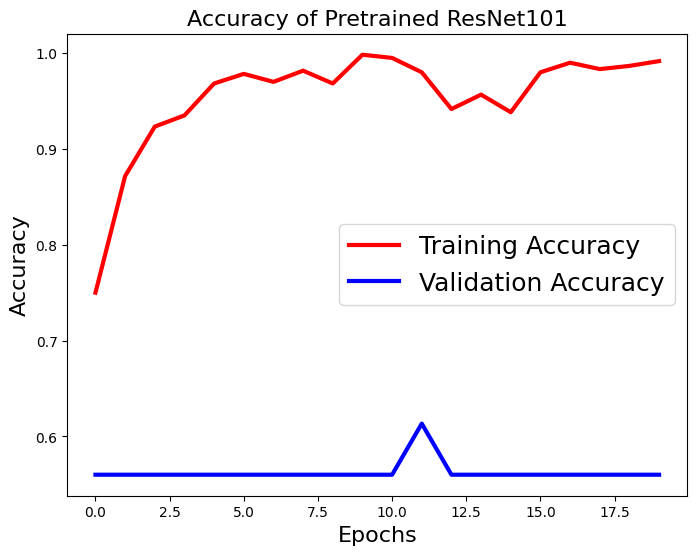

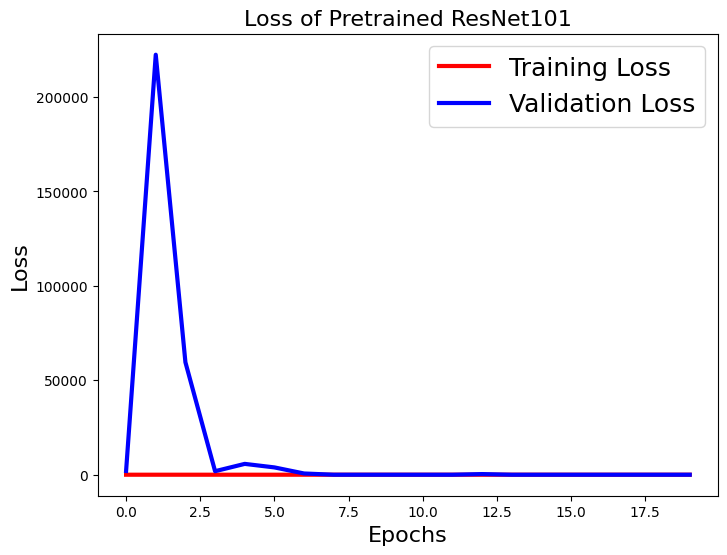

In [34]:
# Load the pre-trained ResNet101 model
base_model, model_name = ResNet(pretrained=True, input_shape=input_shape, model_name="ResNet101")

# Train the model with the pre-trained ResNet101 base
resnet101_pretrained_accuracy = train_model(base_model, model_name)

# Print out the accuracy achieved for the pre-trained ResNet101 model
print(f"{model_name} achieved accuracy: {resnet101_pretrained_accuracy}")

3.8

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.7833 - loss: 0.7287 - val_accuracy: 0.4400 - val_loss: 3343.6875
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.8750 - loss: 0.5510 - val_accuracy: 0.5600 - val_loss: 172743.2344
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.8983 - loss: 0.3887 - val_accuracy: 0.5600 - val_loss: 5006.3340
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9350 - loss: 0.1938 - val_accuracy: 0.5600 - val_loss: 8304.8457
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.9367 - loss: 0.1589 - val_accuracy: 0.5600 - val_loss: 534.1573
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.9717 - loss: 0.0888 - val_accuracy: 0.5600 - val_loss: 5.9588
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.9700 - loss: 0.0769 - val_accuracy: 0.4400 - val_loss: 0.7818
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9833 - loss: 0.0471 - v

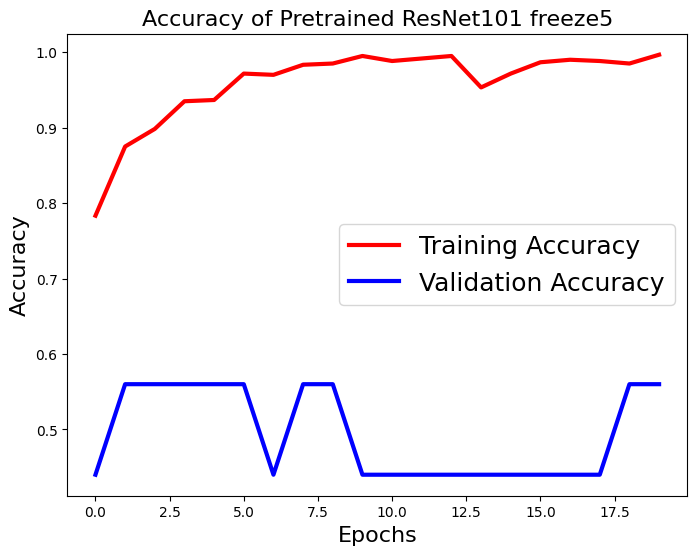

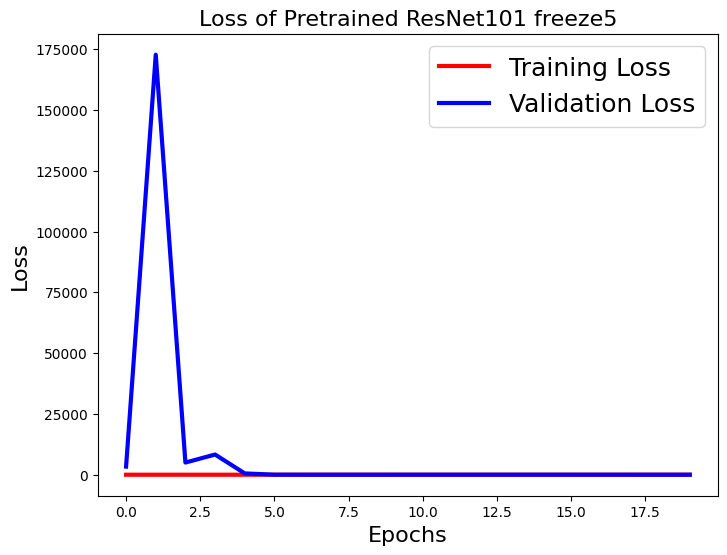

In [35]:
# Load the pre-trained ResNet101 model
base_model, model_name = ResNet(pretrained=True, input_shape=input_shape, model_name="ResNet101")

# Freeze the first 5 layers of the model
base_model = freeze_layers(base_model, 5)

# Train the model with the frozen layers
resnet101_freeze5_accuracy = train_model(base_model, model_name + " freeze5")

# Print out the accuracy achieved for the ResNet101 model with 5 frozen layers
print(f"{model_name} with 5 frozen layers achieved accuracy: {resnet101_freeze5_accuracy}")

3.9

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - accuracy: 0.7383 - loss: 1.2712 - val_accuracy: 0.5600 - val_loss: 652.8110
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.8900 - loss: 0.3863 - val_accuracy: 0.4400 - val_loss: 16.5970
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.8900 - loss: 0.3521 - val_accuracy: 0.5600 - val_loss: 1222.5649
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.9267 - loss: 0.3044 - val_accuracy: 0.5600 - val_loss: 4.7872
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9400 - loss: 0.1948 - val_accuracy: 0.5600 - val_loss: 12.2201
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9450 - loss: 0.1574 - val_accuracy: 0.4400 - val_loss: 4.7749
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9383 - loss: 0.2075 - val_accuracy: 0.4400 - val_loss: 0.7235
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.9467 - loss: 0.2205 - val_accura

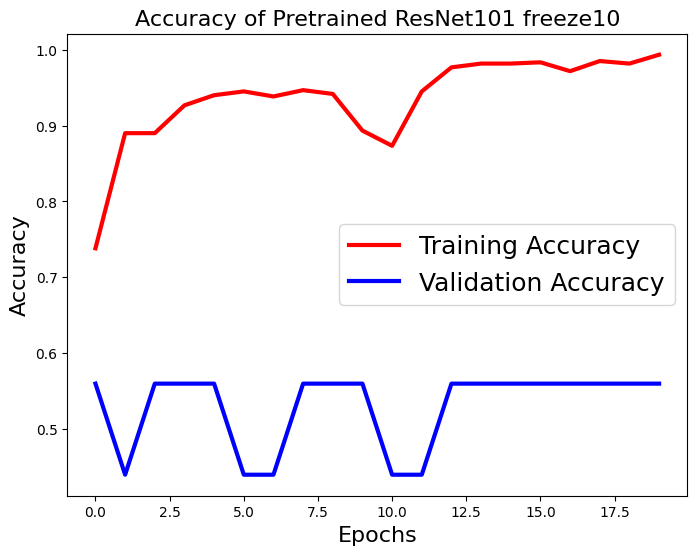

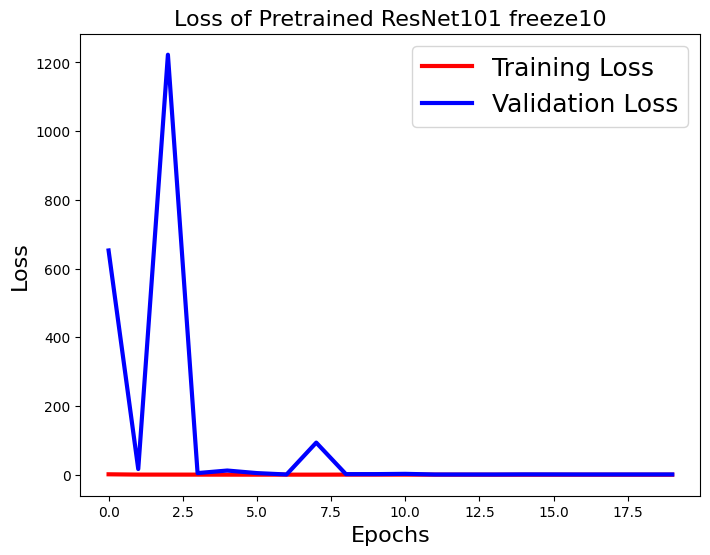

In [15]:
# Load the pre-trained ResNet101 model
base_model, model_name = ResNet(pretrained=True, input_shape=input_shape, model_name="ResNet101")

# Freeze the first 10 layers of the model
base_model = freeze_layers(base_model, 10)

# Train the model with the frozen layers
resnet101_freeze10_accuracy = train_model(base_model, model_name + " freeze10")

# Print out the accuracy achieved for the ResNet101 model with 10 frozen layers
print(f"{model_name} with 10 frozen layers achieved accuracy: {resnet101_freeze10_accuracy}")

3.10

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.7467 - loss: 1.2119 - val_accuracy: 0.4400 - val_loss: 137493904.0000
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.8633 - loss: 0.3190 - val_accuracy: 0.5600 - val_loss: 1678794.2500
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.9233 - loss: 0.2458 - val_accuracy: 0.5600 - val_loss: 7025451.5000
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.9083 - loss: 0.5324 - val_accuracy: 0.4400 - val_loss: 146616.8281
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.7750 - loss: 0.9112 - val_accuracy: 0.5600 - val_loss: 1917688.3750
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.8383 - loss: 0.3396 - val_accuracy: 0.5600 - val_loss: 6625.3950
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.8683 - loss: 0.2960 - val_accuracy: 0.5600 - val_loss: 264.4907
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.895

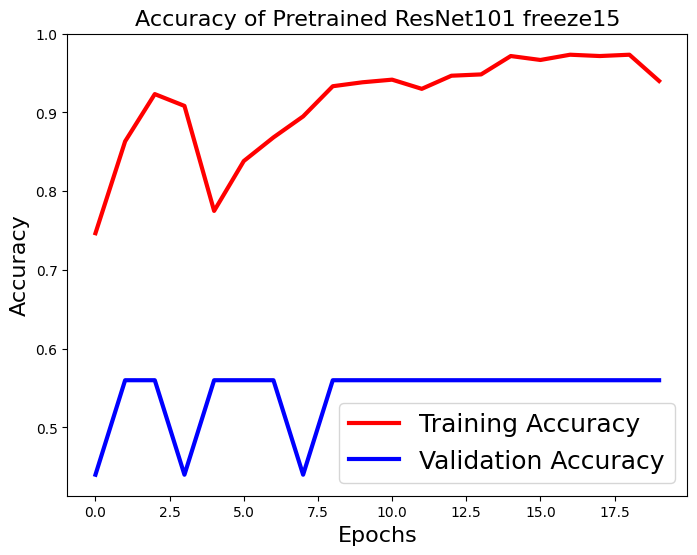

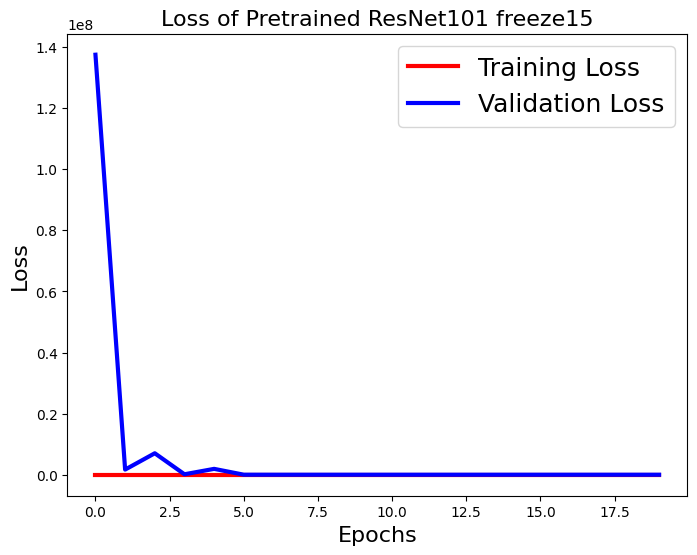

In [16]:
# Load the pre-trained ResNet101 model
base_model, model_name = ResNet(pretrained=True, input_shape=input_shape, model_name="ResNet101")

# Freeze the first 15 layers of the model
base_model = freeze_layers(base_model, 15)

# Train the model with the frozen layers
resnet101_freeze15_accuracy = train_model(base_model, model_name + " freeze15")

# Print out the accuracy achieved for the ResNet101 model with 15 frozen layers
print(f"{model_name} with 15 frozen layers achieved accuracy: {resnet101_freeze15_accuracy}")

In [23]:
from tensorflow.keras import layers, models

def build_transfer_model(base_model, input_shape):

    inputs = layers.Input(shape=input_shape)

    x = base_model(inputs, training=False)   # ❗ IMPORTANT

    x = layers.GlobalAveragePooling2D()(x)   # ❗ converts (2,2,1536) → (1536)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(1, activation='sigmoid')(x)  # binary output

    model = models.Model(inputs, x)

    return model

In [24]:
def train_model(base_model, model_name, train_x, train_y, test_x, test_y, epochs=10, batch_size=32):

    model = build_transfer_model(base_model, input_shape)  # ❗ THIS LINE IS KEY

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_x,
        train_y,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(test_x, test_y)
    )

    plot_accuracy(history, model_name)
    plot_loss(history, model_name)

    loss, acc = model.evaluate(test_x, test_y)

    return acc

3.11

In [25]:
def preprocess_data_resized():

    train_x, train_y, test_x, test_y = load_dataset()

    train_x_resized = np.array([cv2.resize(img, (128,128)) for img in train_x])
    test_x_resized  = np.array([cv2.resize(img, (128,128)) for img in test_x])

    train_x_resized = train_x_resized / 255.
    test_x_resized  = test_x_resized / 255.

    return train_x_resized, train_y, test_x_resized, test_y

In [17]:
train_x, train_y, test_x, test_y = preprocess_data_resized()

input_shape = (128, 128, 3)

In [18]:
print(train_x.shape)

(600, 128, 128, 3)


Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 250s 5s/step - accuracy: 0.7683 - loss: 0.5533 - val_accuracy: 0.4467 - val_loss: 0.7233
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 46s 222ms/step - accuracy: 0.9067 - loss: 0.2323 - val_accuracy: 0.5600 - val_loss: 1.4060
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.9683 - loss: 0.0959 - val_accuracy: 0.5600 - val_loss: 2.5326
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.9467 - loss: 0.1433 - val_accuracy: 0.5600 - val_loss: 2.3232
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.9683 - loss: 0.0985 - val_accuracy: 0.5600 - val_loss: 2.1191
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - accuracy: 0.9517 - loss: 0.1361 - val_accuracy: 0.5600 - val_loss: 1.6078
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.9817 - loss: 0.0576 - val_accuracy: 0.5600 - val_loss: 2.2244
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 225ms/step - accuracy: 0.9950 - loss: 0.0346 - val_accuracy: 0.

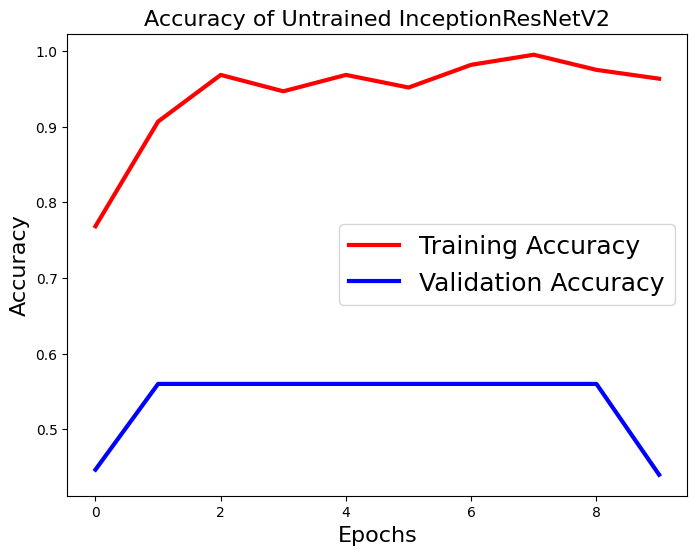

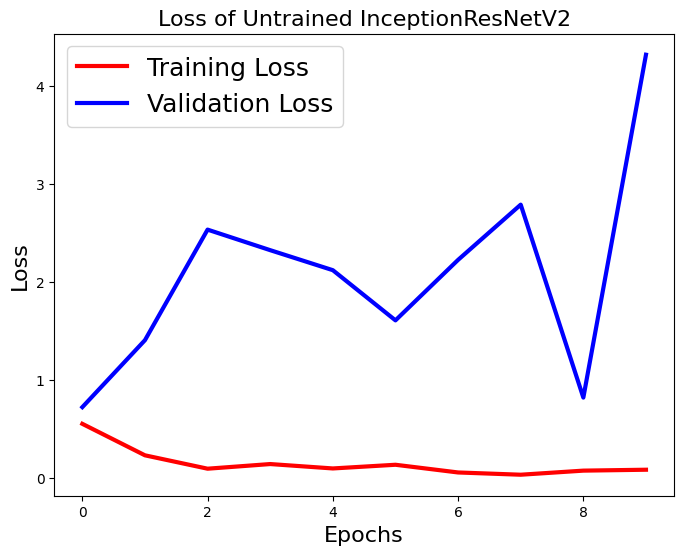

In [29]:
base_model, model_name = ResNet(
    pretrained=False,
    input_shape=input_shape,
    model_name="InceptionResNetV2"
)

inception_untrained_accuracy = train_model(
    base_model,
    model_name,
    train_x,
    train_y,
    test_x,
    test_y
)

print(f"{model_name} achieved accuracy: {inception_untrained_accuracy}")

3.12

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 231s 4s/step - accuracy: 0.8833 - loss: 0.3221 - val_accuracy: 0.6333 - val_loss: 3.6471
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 225ms/step - accuracy: 0.9767 - loss: 0.0777 - val_accuracy: 0.5800 - val_loss: 3.4188
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step - accuracy: 0.9833 - loss: 0.0561 - val_accuracy: 0.7533 - val_loss: 0.6120
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 229ms/step - accuracy: 0.9883 - loss: 0.0399 - val_accuracy: 0.9667 - val_loss: 0.1423
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 225ms/step - accuracy: 0.9817 - loss: 0.0625 - val_accuracy: 0.8533 - val_loss: 0.8160
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.9933 - loss: 0.0270 - val_accuracy: 0.5600 - val_loss: 6.2733
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 254ms/step - accuracy: 0.9883 - loss: 0.0338 - val_accuracy: 0.4600 - val_loss: 4.1743
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step - accuracy: 0.9833 - loss: 0.0751 - val_accuracy: 0.6

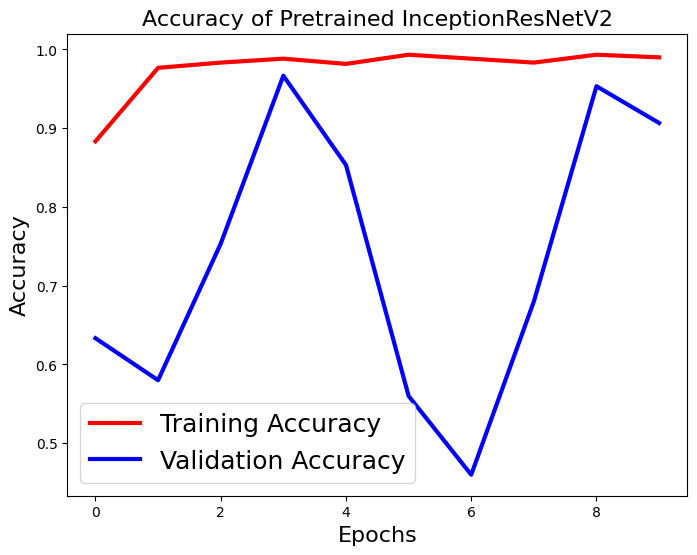

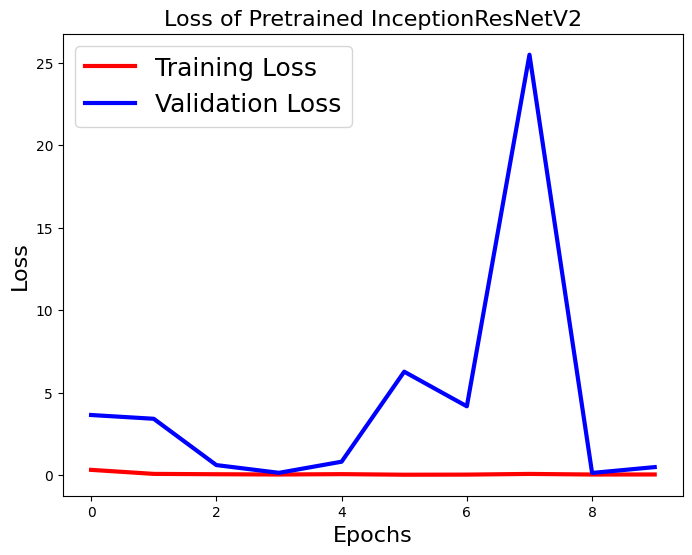

In [31]:
base_model, model_name = ResNet(
    pretrained=True,
    input_shape=input_shape,
    model_name="InceptionResNetV2"
)

acc_inception_pretrained = train_model(
    base_model,
    model_name,
    train_x,
    train_y,
    test_x,
    test_y
)

print(f"{model_name} achieved accuracy: {acc_inception_pretrained}")

3.13

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 240s 5s/step - accuracy: 0.8050 - loss: 0.4355 - val_accuracy: 0.4400 - val_loss: 3.3953
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - accuracy: 0.9717 - loss: 0.0859 - val_accuracy: 0.5533 - val_loss: 0.7523
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.9883 - loss: 0.0371 - val_accuracy: 0.7200 - val_loss: 0.5510
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.9883 - loss: 0.0357 - val_accuracy: 0.9533 - val_loss: 0.2546
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - accuracy: 0.9950 - loss: 0.0198 - val_accuracy: 0.9667 - val_loss: 0.2632
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - accuracy: 0.9900 - loss: 0.0257 - val_accuracy: 0.9400 - val_loss: 0.1483
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.9900 - loss: 0.0310 - val_accuracy: 0.9733 - val_loss: 0.1012
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.9967 - loss: 0.0211 - val_accuracy: 0.9

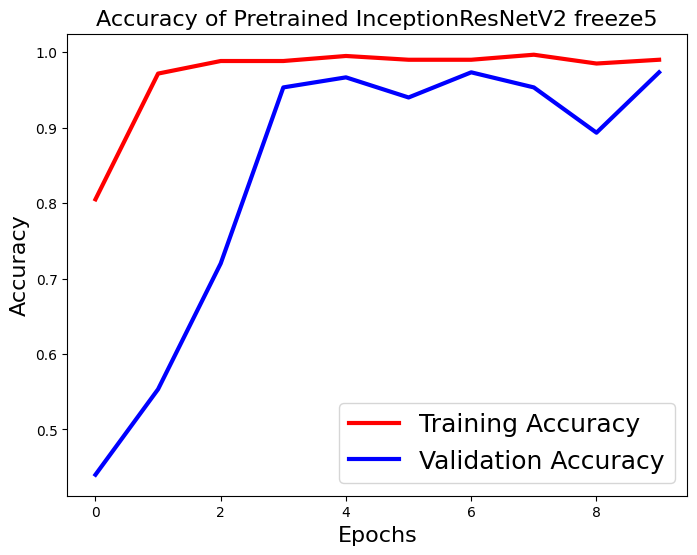

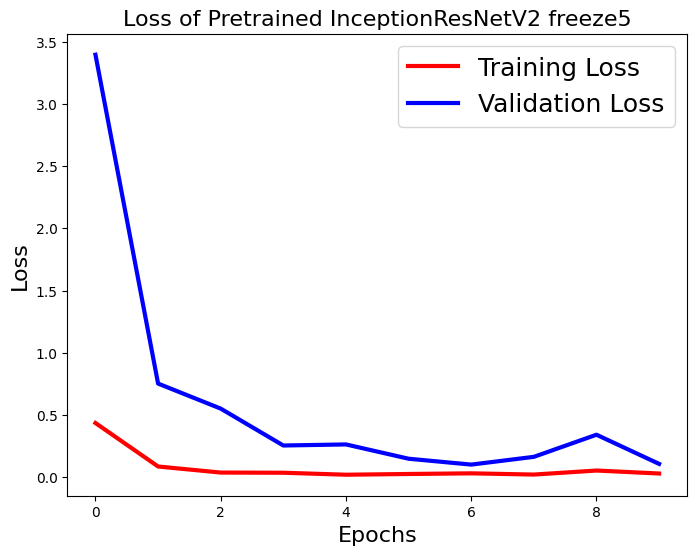

In [32]:
base_model, model_name = ResNet(
    pretrained=True,
    input_shape=input_shape,
    model_name="InceptionResNetV2"
)

base_model = freeze_layers(base_model, 5)

acc_inception_freeze5 = train_model(
    base_model,
    model_name + " freeze5",
    train_x,
    train_y,
    test_x,
    test_y
)

print(f"{model_name} freeze5 accuracy: {acc_inception_freeze5}")

3.14

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 251s 5s/step - accuracy: 0.8300 - loss: 0.3602 - val_accuracy: 0.5600 - val_loss: 34.3128
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.9617 - loss: 0.1332 - val_accuracy: 0.4467 - val_loss: 3.4157
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.9750 - loss: 0.0739 - val_accuracy: 0.8200 - val_loss: 0.6038
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - accuracy: 0.9967 - loss: 0.0187 - val_accuracy: 0.8000 - val_loss: 0.5861
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.9917 - loss: 0.0477 - val_accuracy: 0.9733 - val_loss: 0.1494
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.9967 - loss: 0.0120 - val_accuracy: 0.9867 - val_loss: 0.1351
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - accuracy: 0.9917 - loss: 0.0289 - val_accuracy: 0.8333 - val_loss: 1.7499
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.9950 - loss: 0.0146 - val_accuracy: 0.

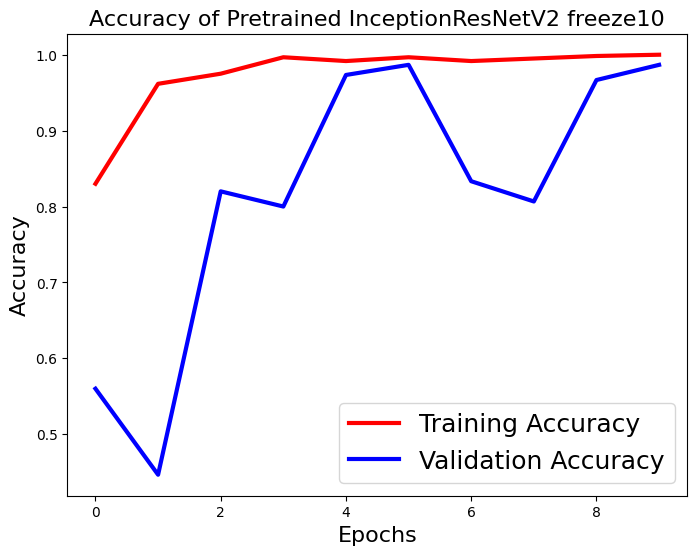

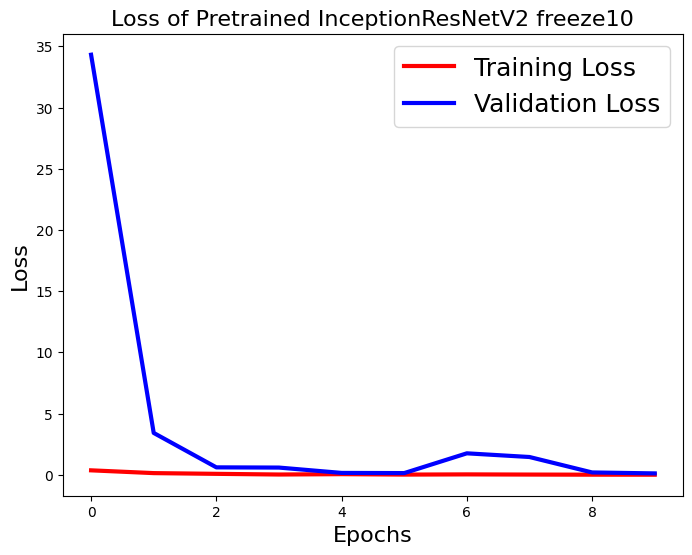

In [19]:
base_model, model_name = ResNet(
    pretrained=True,
    input_shape=input_shape,
    model_name="InceptionResNetV2"
)

base_model = freeze_layers(base_model, 10)

acc_inception_freeze10 = train_model(
    base_model,
    model_name + " freeze10",
    train_x,
    train_y,
    test_x,
    test_y
)

print(f"{model_name} freeze10 accuracy: {acc_inception_freeze10}")

3.15

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 224s 4s/step - accuracy: 0.8233 - loss: 0.3765 - val_accuracy: 0.6000 - val_loss: 2.0340
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.9767 - loss: 0.1162 - val_accuracy: 0.6667 - val_loss: 0.6448
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.9817 - loss: 0.0556 - val_accuracy: 0.7933 - val_loss: 2.2392
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.9900 - loss: 0.0274 - val_accuracy: 0.7600 - val_loss: 5.4398
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.9933 - loss: 0.0291 - val_accuracy: 0.9933 - val_loss: 0.0464
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.9867 - loss: 0.0464 - val_accuracy: 0.9733 - val_loss: 0.1410
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.9933 - loss: 0.0187 - val_accuracy: 0.9867 - val_loss: 0.0804
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.9967 - loss: 0.0101 - val_accuracy: 0.9

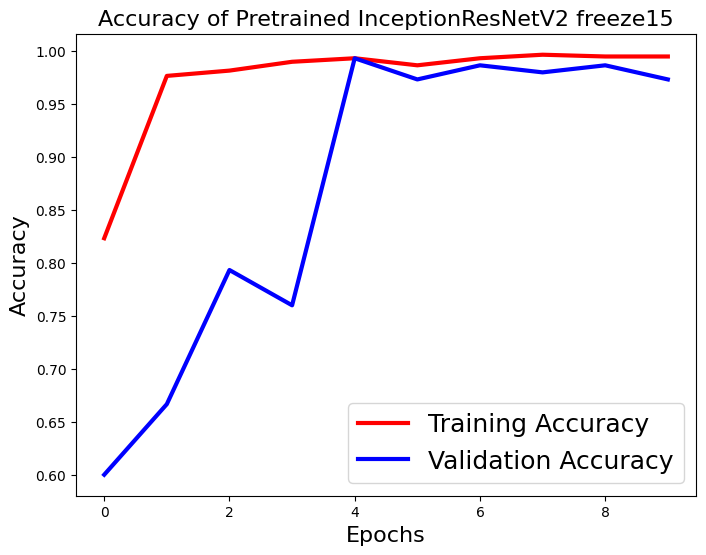

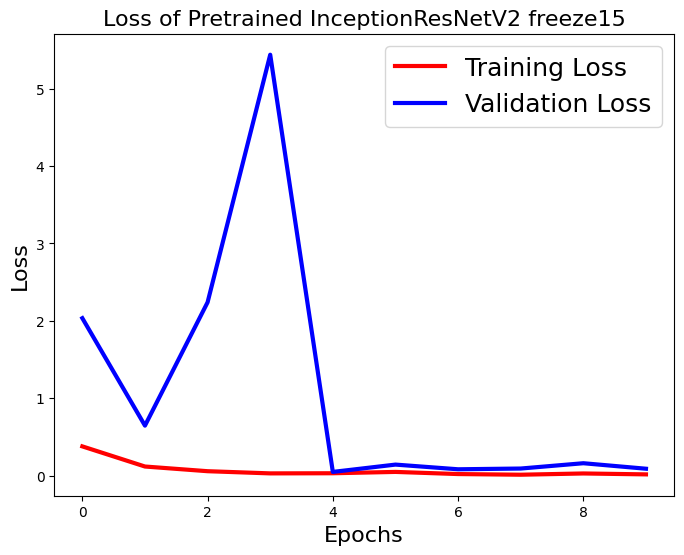

In [20]:
base_model, model_name = ResNet(
    pretrained=True,
    input_shape=input_shape,
    model_name="InceptionResNetV2"
)

base_model = freeze_layers(base_model, 15)

acc_inception_freeze15 = train_model(
    base_model,
    model_name + " freeze15",
    train_x,
    train_y,
    test_x,
    test_y
)

print(f"{model_name} freeze15 accuracy: {acc_inception_freeze15}")

### 2.2.8 CNN Use Case No.3: Your choice

**TODO**: Select one application other than VGG or ResNet from [here](https://www.tensorflow.org/api_docs/python/tf/keras/applications) and implement it the same way you did with VGG & ResNet.

**Note**: *You will need to experiment it in both pretrained (both with or without layers freezing) and also untrained, in the test section.*

**Make sure to add the following to the report:**


*   The name of the chosen model, plots and accuracy achieved using this model untrained, pre-trained, and pre-trained with layer freezing with different number of frozen layers (from 4.1 till 4.5 in the report)


In [21]:
from tensorflow.keras import applications

def CNN_App(pretrained=True, input_shape=(64,64,3), model_name="Xception"):
    """
    Returns the Xception model (pretrained or untrained)
    Args:
        pretrained (bool): Whether to load pretrained weights from ImageNet
        input_shape (tuple): Input shape of the images
        model_name (str): Name of the model, default is "Xception"
    """

    if pretrained:
        model_name = "Pretrained " + model_name
        base_model = applications.Xception(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape,
            pooling='none'
        )
    else:
        model_name = "Untrained " + model_name
        base_model = applications.Xception(
            weights=None,
            include_top=False,
            input_shape=input_shape,
            pooling='none'
        )

    return base_model, model_name

4.1

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.7067 - loss: 1.2940 - val_accuracy: 0.4400 - val_loss: 0.6932
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.9000 - loss: 0.2482 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.8917 - loss: 0.2542 - val_accuracy: 0.5600 - val_loss: 0.6931
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.9567 - loss: 0.1126 - val_accuracy: 0.4400 - val_loss: 0.6932
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.9517 - loss: 0.1795 - val_accuracy: 0.4400 - val_loss: 0.6933
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.9283 - loss: 0.2217 - val_accuracy: 0.4400 - val_loss: 0.6934
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.9350 - loss: 0.1573 - val_accuracy: 0.4400 - val_loss: 0.6942
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - accuracy: 0.9683 - loss: 0.1452 - val_accuracy: 0.4

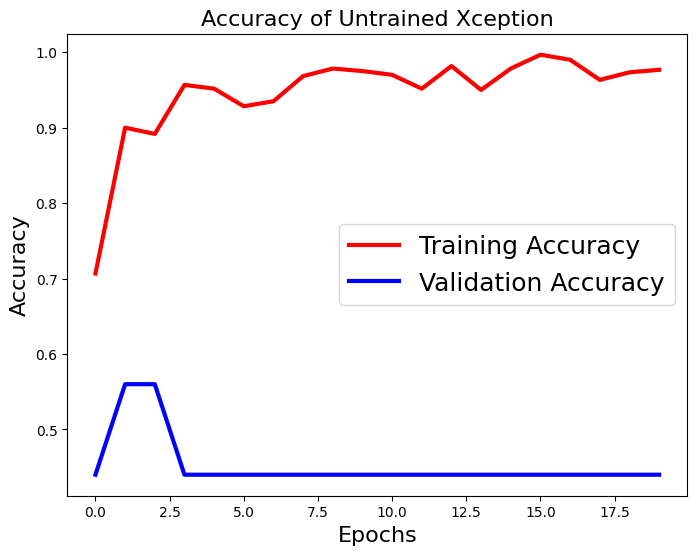

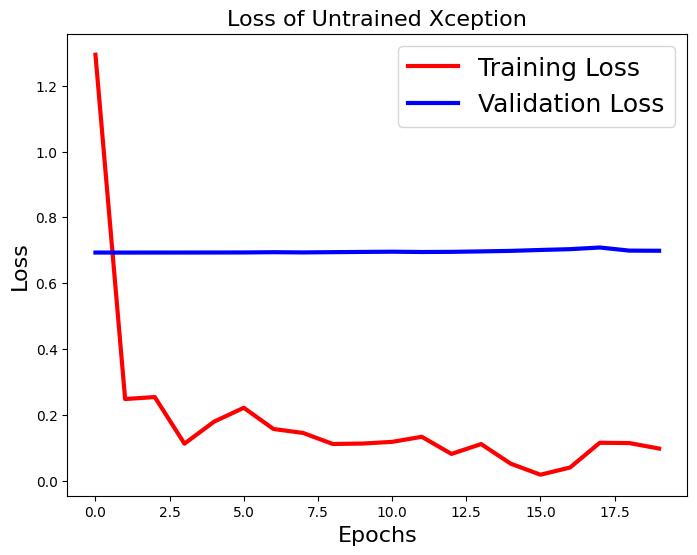

In [30]:
# Load the untrained Xception model
base_model, model_name = CNN_App(pretrained=False, input_shape=input_shape, model_name="Xception")

# Train the model with the untrained Xception base
xception_untrained_accuracy = train_model(base_model, model_name)

# Print out the accuracy achieved for the untrained Xception model
print(f"{model_name} achieved accuracy: {xception_untrained_accuracy}")

4.2

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.4900 - loss: 0.9008 - val_accuracy: 0.4800 - val_loss: 0.6896
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.5017 - loss: 0.6932 - val_accuracy: 0.4800 - val_loss: 0.6941
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.4900 - loss: 0.6932 - val_accuracy: 0.3667 - val_loss: 0.6944
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.5033 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6936
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.5083 - loss: 0.6932 - val_accuracy: 0.4867 - val_loss: 0.6932
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.4783 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.4817 - loss: 0.6932 - val_accuracy: 0.4400 - val_loss: 0.6932
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - a

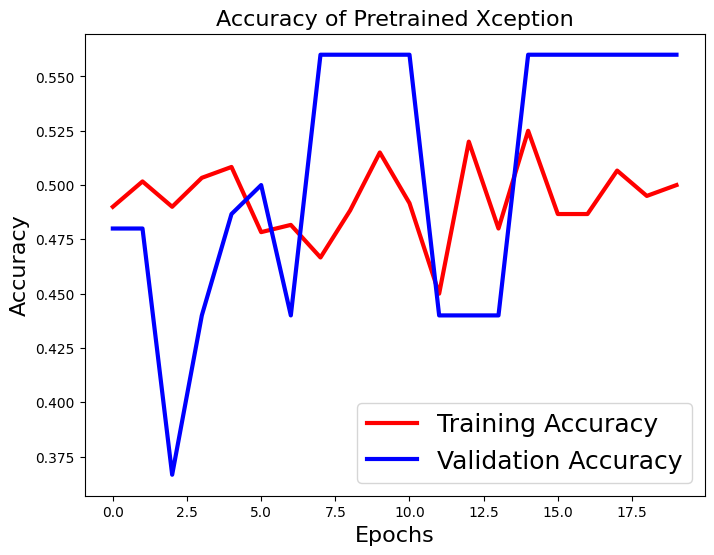

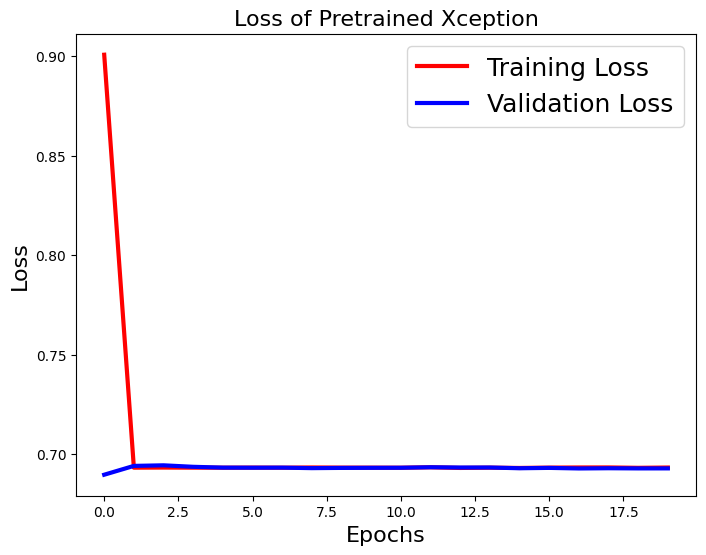

In [31]:
# Load the pre-trained Xception model
base_model, model_name = CNN_App(pretrained=True, input_shape=input_shape, model_name="Xception")

# Train the model with the pre-trained Xception base
xception_pretrained_accuracy = train_model(base_model, model_name)

# Print out the accuracy achieved for the pre-trained Xception model
print(f"{model_name} achieved accuracy: {xception_pretrained_accuracy}")

4.3

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.4850 - loss: 0.7878 - val_accuracy: 0.4400 - val_loss: 0.7626
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.5000 - loss: 0.6771 - val_accuracy: 0.4400 - val_loss: 0.8905
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.6450 - loss: 0.5679 - val_accuracy: 0.4400 - val_loss: 2.6346
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - accuracy: 0.8600 - loss: 0.4675 - val_accuracy: 0.7533 - val_loss: 1.2068
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.8233 - loss: 0.3992 - val_accuracy: 0.6867 - val_loss: 6.1193
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.9417 - loss: 0.1520 - val_accuracy: 0.5733 - val_loss: 11.7303
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.9567 - loss: 0.1642 - val_accuracy: 0.8000 - val_loss: 15.7403
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.9567 - loss: 0.0921 - val_accuracy: 0.

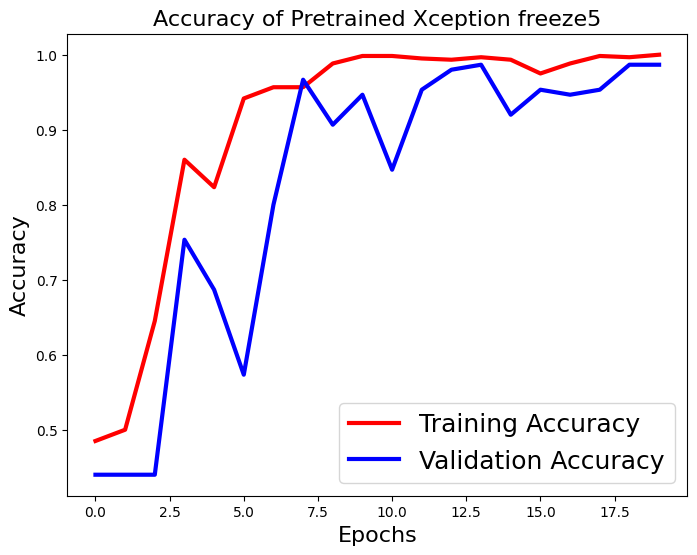

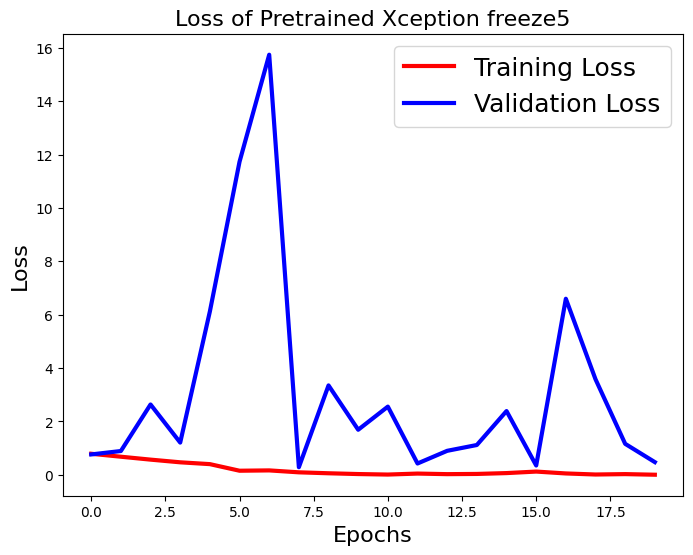

In [32]:
# Load the pre-trained Xception model
base_model, model_name = CNN_App(pretrained=True, input_shape=input_shape, model_name="Xception")

# Freeze the first 5 layers of the model
base_model = freeze_layers(base_model, 5)

# Train the model with the frozen layers
xception_freeze5_accuracy = train_model(base_model, model_name + " freeze5")

# Print out the accuracy achieved for the Xception model with 5 frozen layers
print(f"{model_name} with 5 frozen layers achieved accuracy: {xception_freeze5_accuracy}")

4.4

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.5300 - loss: 0.7078 - val_accuracy: 0.6000 - val_loss: 0.6703
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.6667 - loss: 0.6107 - val_accuracy: 0.6200 - val_loss: 4.7863
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.7633 - loss: 0.4683 - val_accuracy: 0.7600 - val_loss: 9.2355
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.8233 - loss: 0.4862 - val_accuracy: 0.7133 - val_loss: 57.1017
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.8000 - loss: 0.3964 - val_accuracy: 0.5533 - val_loss: 20.6935
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.7783 - loss: 0.3245 - val_accuracy: 0.8600 - val_loss: 2.8648
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.8767 - loss: 0.2685 - val_accuracy: 0.7533 - val_loss: 3.6504
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.9717 - loss: 0.0990 - val_accuracy: 0.

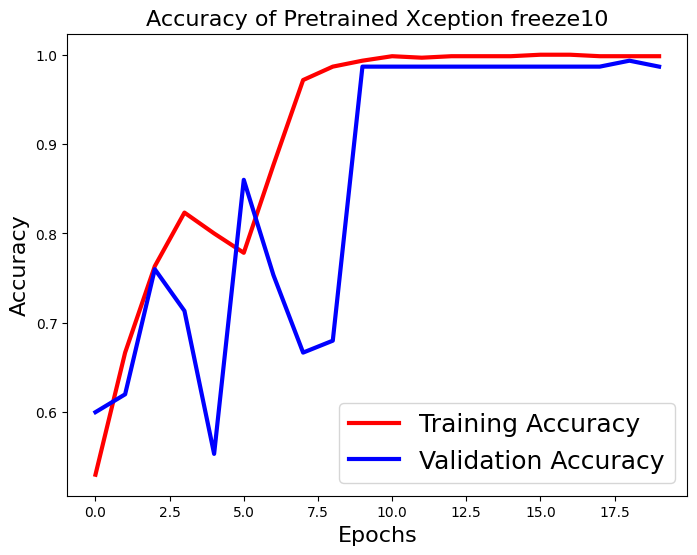

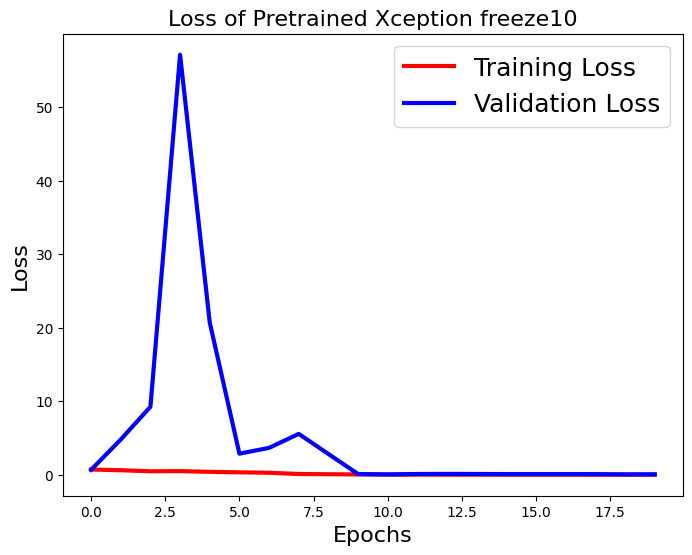

In [33]:
# Load the pre-trained Xception model
base_model, model_name = CNN_App(pretrained=True, input_shape=input_shape, model_name="Xception")

# Freeze the first 10 layers of the model
base_model = freeze_layers(base_model, 10)

# Train the model with the frozen layers
xception_freeze10_accuracy = train_model(base_model, model_name + " freeze10")

# Print out the accuracy achieved for the Xception model with 10 frozen layers
print(f"{model_name} with 10 frozen layers achieved accuracy: {xception_freeze10_accuracy}")

4.5

In [ ]:
# Load the pre-trained Xception model
base_model, model_name = CNN_App(pretrained=True, input_shape=input_shape, model_name="Xception")

# Freeze the first 15 layers of the model
base_model = freeze_layers(base_model, 15)

# Train the model with the frozen layers
xception_freeze15_accuracy = train_model(base_model, model_name + " freeze15")

# Print out the accuracy achieved for the Xception model with 15 frozen layers
print(f"{model_name} with 15 frozen layers achieved accuracy: {xception_freeze15_accuracy}")

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6983 - loss: 0.5767 - val_accuracy: 0.6733 - val_loss: 21.1399
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 307ms/step - accuracy: 0.6350 - loss: 0.4308 - val_accuracy: 0.6600 - val_loss: 49.8993
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.8300 - loss: 0.4570 - val_accuracy: 0.6867 - val_loss: 20.9031
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy: 0.8129 - loss: 0.3825 

### 2.2.9 Layers Freezing

The following utility method is used for layers freezing.

**TODO**: *Experiment all the pretrained models with layers freezing using* **different number of frozen layers**.

**NOTE**: You will not change this method at all, the experimenting will take place in the test cases section below.

In [ ]:
def freeze(model, number_of_frozen_layers):
    layers = model.layers

    layers = layers[:number_of_frozen_layers]

    for layer in layers:
        layer.trainable = False

    return model

### 2.2.10 Make your models

You can use the following utility method to make the model you desire, **modify it if you please**.

In [ ]:
def make_model(pretrained=True, freeze_layers=False, number_of_frozen_layers=0, model_selection="VGG"):
    """
    Use this method to create models
    Args:
      pretrained (Bool): Whether make the model pretrained or not, doesn't apply to custom CNN.
      freeze_layers (Bool): Whether apply layers freezing on pretrained networks or not.
      number_of_frozen_layers (int): Number of frozen layers.
      model_selection (Str): Must be exactly "Custom", or "VGG", or "ResNet" or anything else for CNN_App
    """
    # ==================================================================== TAKE CARE ==========================================================================
    # You might need to make the input shape an additional parameter to the function instead of being statically defined here
    # This will help you configure the input_shape when you handle the error due to the vanishing input dimensions in very deep networks like inception_resnetV2
    input_shape = (64, 64, 3)

    if model_selection == "Custom":
        model, model_name = CustomCNN(input_shape)
    elif model_selection == "VGG":
        model, model_name = VGG(pretrained, input_shape)
    elif model_selection == "ResNet":
        model, model_name = ResNet(pretrained, input_shape)
    else:
        model, model_name = CNN_App(pretrained, input_shape)

    if model_selection != "Custom":
        if freeze_layers:
            model = freeze(model, number_of_frozen_layers)
            model_name = model_name + " with " + str(number_of_frozen_layers) + " Frozen Layers"

        ## Add classification head for non custom models
        y = model.output
        y = Flatten()(y)
        y = Dense(256, activation='relu')(y)
        y = Dense(1, activation='sigmoid', name='fc')(y)

        model = Model(inputs=model.input, outputs=y)

    return model, model_name

### 2.2.11 Testing model utility method

This is a generic method that will be used to test all the implemented models, a modular design allows you to experiment more clearly. **Modify it if you please.**

**TODO**:

1. Try different [optimizers](https://keras.io/api/optimizers/) and report their affect on the **results** and plots.
2. For each optimizer, try different learning rates and other hyperparameters (If applicable), and report the difference on the **results** and plots.
3. Try different [loss functions](https://keras.io/api/losses/), and report their affect on **accuracy** and plots.

**IMPORTANT NOTE**: You don't need to try different optimizers, learning rates and hyperparameters, and losses on all models, **just find the best model with the current optimizers, rates and hyperparameters & losses** **then try your experiments** (changing optimizers, rates and hyperparameters & losses) only on this best model.

***The best model is obtained after testing the different models defined above in different cases (untrained, pretrained without freezing, and pretrained with different number of frozen layers) and choosing the model case giving the best performance***

**Make sure to add the following to the report:**


*   The best model found and its accuracy before tuning (5.1 in the report)
*   Include the default case for the optimizer and its hyperparameters using SGD(lr=0.0001, momentum=0.9, nesterov=True) (5.2 in the report)
*   Experiment with other combinations of optimizers and their hyperparameters (5.3, 5.4, 5.5, 5.6 in the report)
*   Include the default case for the loss using Binary Crossentropy (5.7 in the report)
*   Try out two other loss functions (5.8, 5.9 in the report)


In [ ]:
def test_model(model, model_name, epochs=10, print_summary=True, plot_results=True):
    '''TODO: Experiment with different optimizers, learning rates and hyperparameters, and losses on the best model'''

    sgd = SGD(lr=0.0001, momentum=0.9, nesterov=True)
    model.compile(optimizer=sgd, loss='binary_crossentropy', metrics=['accuracy'])

    if (print_summary):
        model.summary()

    hist = model.fit(train_x, train_y, validation_data = (test_x, test_y), verbose=1, epochs=epochs, batch_size=32)
    preds = model.evaluate(test_x, test_y, batch_size=32, verbose=1, sample_weight=None)

    print ("Validation Loss = " + str(preds[0]))
    print ("Validation Accuracy = " + str(preds[1]))

    if(plot_results):
        plot_loss(hist, model_name)
        plot_accuracy(hist, model_name)

### 2.2.12 Create your model test cases.

**TODO**: Fill here all the test cases methods that you want to apply.

Add methods (Untrained, pretrained & pretrained with freezing) for *(at least)*:
1. ResNet()
2. CNN_App()

**NOTE**: *Those test cases, don't change use case types (i.e. you will need to change the VGG in VGG() method to VGG19 and re test again or make another function for VGG19 for example) and doesn't change the loss function nor the optimizer type (these need to be changed in the testing utility method).*


In [ ]:
def test_custom_CNN(epochs=20, print_summary=True, plot_results=True):
    model, model_name = make_model(False, False, 0, "Custom")
    test_model(model, model_name, epochs, print_summary, plot_results)

In [ ]:
def test_untrained_VGG(epochs=20, print_summary=True, plot_results=True):
    model, model_name = make_model(False, False, 0, "VGG")
    test_model(model, model_name, epochs, print_summary, plot_results)

In [ ]:
def test_pretrained_VGG(epochs=20, print_summary=True, plot_results=True):
    model, model_name = make_model(True, False, 0, "VGG")
    test_model(model, model_name, epochs, print_summary, plot_results)

In [ ]:
def test_pretrained_layers_freezing_VGG(epochs=20, print_summary=True, plot_results=True):
    model, model_name = make_model(True, True, 5, "VGG")
    test_model(model, model_name, epochs, print_summary, plot_results)

###  2.2.13 Test your models

**TODO**: Call all your defined methods for testing here.

**Note**: You might want to go up to **1000** epochs for the untrained model if the validation accuracy is low.

In [ ]:
test_custom_CNN(20)

In [ ]:
test_untrained_VGG(100)

In [ ]:
test_pretrained_VGG(20)

In [ ]:
test_pretrained_layers_freezing_VGG(20)

## 2.3 Conclusion

That's it! Congratulations on training CNN use cases models.

Make sure you deliver all the requirements for the submission.